Extract and Transform Data

[*********************100%***********************]  4 of 4 completed


Ticker      IBOVESPA      S&P 500     Hang Seng   STOXX 600
Date                                                       
2005-01-03   25722.0  1202.079956  14237.419922  252.550003
2005-01-04   24848.0  1188.050049  14045.900391  253.550003
2005-01-05   24692.0  1183.739990  13764.360352  251.850006
2005-01-06   24367.0  1187.890015  13712.040039  253.089996
2005-01-07   24747.0  1186.189941  13574.860352  254.720001
...              ...          ...           ...         ...
2026-05-22  176210.0  7473.470215  25606.029297  625.119995
2026-05-26  176589.0  7519.120117  25599.449219  628.010010
2026-05-27  175744.0  7520.359863  25328.230469  628.179993
2026-05-28  175063.0  7563.629883  25006.160156  625.109985
2026-05-29  173788.0  7580.060059  25182.390625  626.000000

[4882 rows x 4 columns]


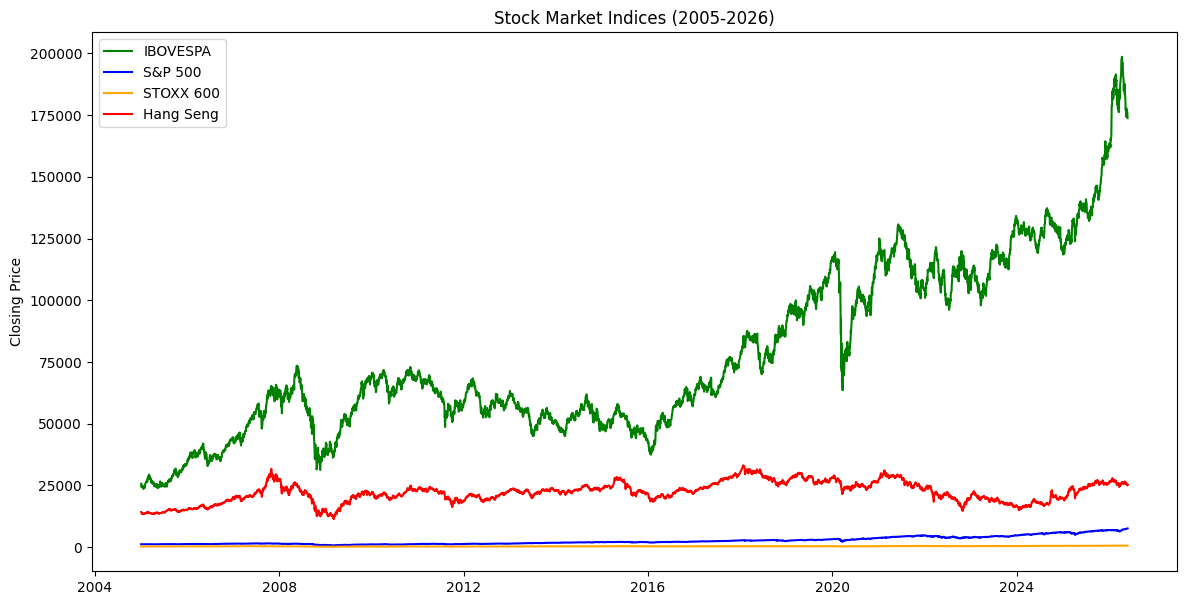

In [1]:
import pandas as pd # Data Extraction and Data Cleaning
import numpy as np # Mathematical Modelling
import matplotlib.pyplot as plt # Graphs
import seaborn as sns # Statistics
from scipy import stats # Statistics
import yfinance as yf # Financial Data
import datetime # Time

# --- Extracting Data and Data Preparation ---

DATA_FINAL = datetime.datetime.now().strftime('2026-05-31')

tickers = [
    '^BVSP',  # Brazil
    '^GSPC',  # USA
    '^STOXX',  # Europe
    '^HSI'  # Hong Kong
]

raw_data = yf.download(tickers, start='2005-01-01', end=DATA_FINAL, auto_adjust=True)['Close']
stock_data = raw_data.copy()

stock_data.rename(columns={
    '^BVSP': 'IBOVESPA',
    '^GSPC': 'S&P 500',
    '^STOXX': 'STOXX 600',
    '^HSI': 'Hang Seng'
}, inplace=True)

stock_data.dropna(inplace=True)
print(stock_data)

# --- Data Visualization of Index Closing Prices --- 
plt.figure(figsize=(14,7))

plt.plot(stock_data.index, stock_data['IBOVESPA'], label='IBOVESPA', color='green')
plt.plot(stock_data.index, stock_data['S&P 500'], label='S&P 500', color='blue')
plt.plot(stock_data.index, stock_data['STOXX 600'], label='STOXX 600', color='orange')
plt.plot(stock_data.index, stock_data['Hang Seng'], label='Hang Seng', color='red')
plt.title('Stock Market Indices (2005-2026)')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(False)
plt.show()

Ticker      IBOVESPA   S&P 500  Hang Seng  STOXX 600
Date                                                
2005-01-04 -0.034569 -0.011740  -0.013543   0.003952
2005-01-05 -0.006298 -0.003634  -0.020248  -0.006727
2005-01-06 -0.013250  0.003500  -0.003808   0.004911
2005-01-07  0.015475 -0.001432  -0.010055   0.006420
2005-01-10 -0.018557  0.003417  -0.003207  -0.000393
...              ...       ...        ...        ...
2026-05-22 -0.008139  0.003720   0.008610   0.007321
2026-05-26  0.002149  0.006090  -0.000257   0.004612
2026-05-27 -0.004797  0.000165  -0.010651   0.000271
2026-05-28 -0.003882  0.005737  -0.012797  -0.004899
2026-05-29 -0.007310  0.002170   0.007023   0.001423

[4881 rows x 4 columns]


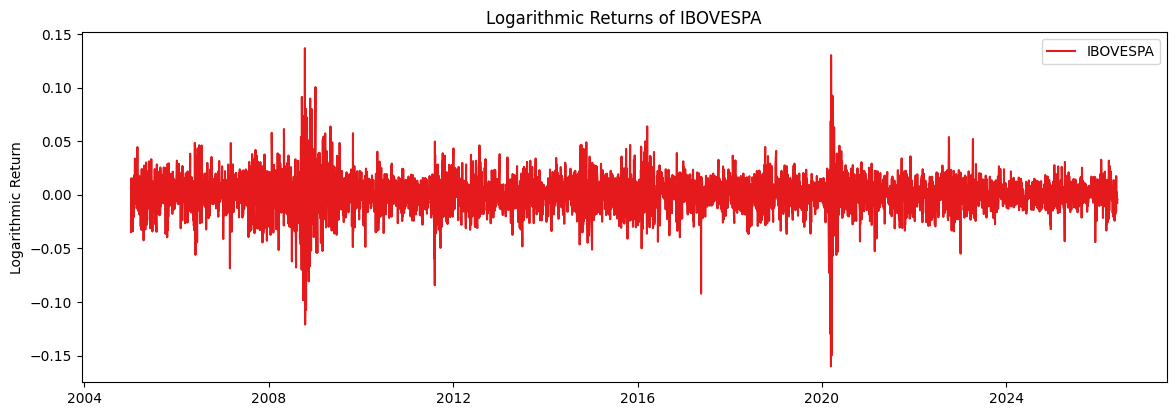

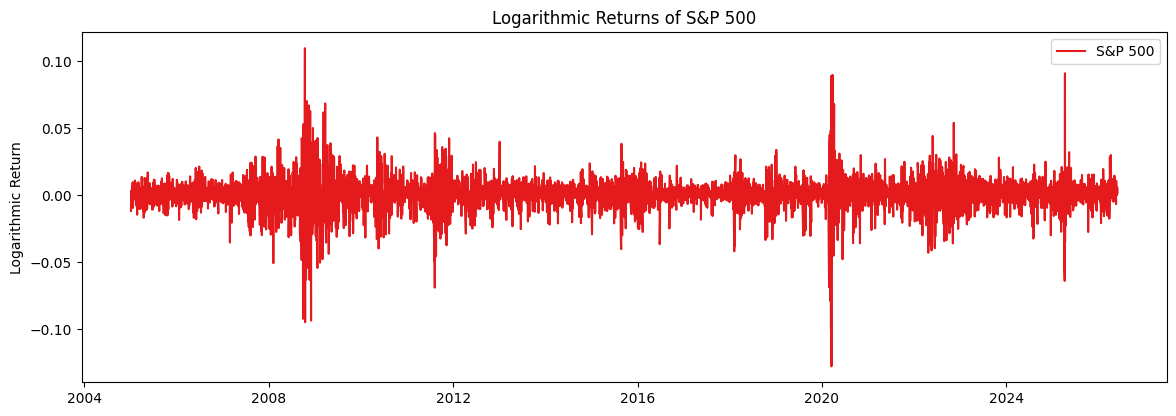

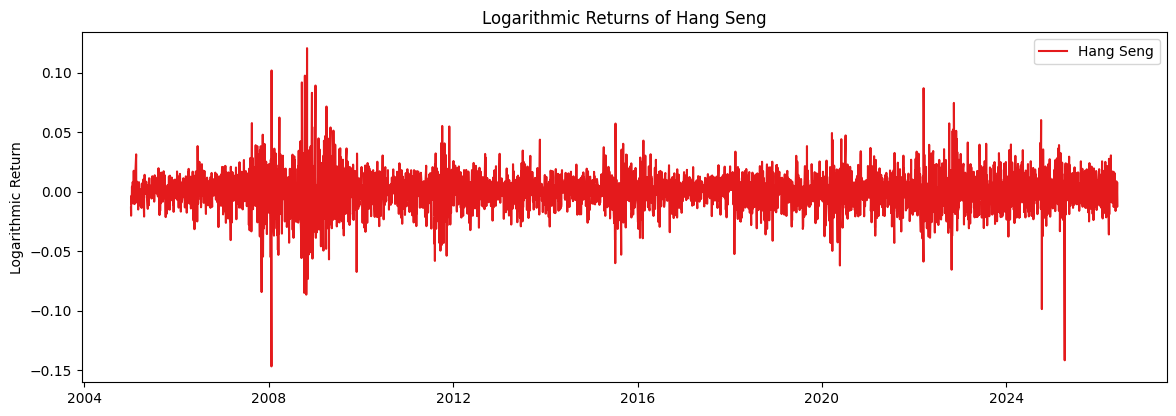

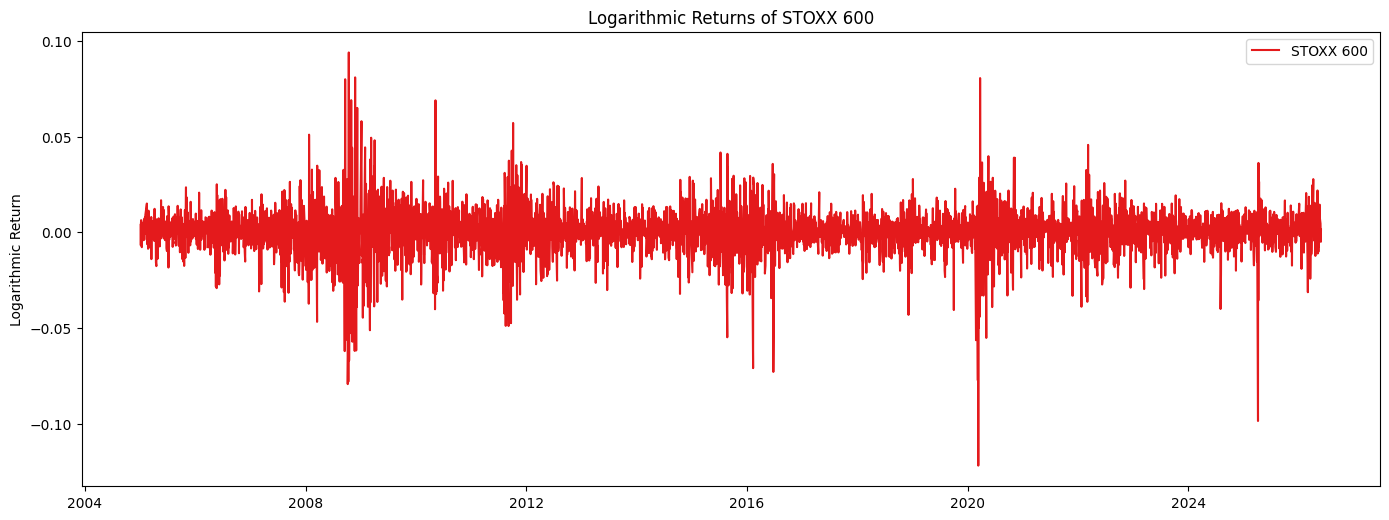

In [2]:
# --- Logarithmic Returns ---

log_market_returns = np.log(stock_data / stock_data.shift(1)).dropna()
print(log_market_returns)
for i in log_market_returns.columns:
    plt.figure(figsize=(14,10))
    plt.subplot(2, 1, 1)
    plt.plot(log_market_returns.index, log_market_returns[i], label=i, color=plt.cm.Set1(0))
    plt.title(f'Logarithmic Returns of {i}')
    plt.ylabel('Logarithmic Return')
    plt.legend()
    plt.grid(False)
plt.tight_layout()
plt.show()

,Mean,Variance,Std Dev,Skewness,Kurtosis
Ticker,,,,,
IBOVESPA,0.000391,0.000287,0.016934,-0.462239,8.739172
S&P 500,0.000377,0.000154,0.012394,-0.566710,12.098519
Hang Seng,0.000117,0.000231,0.015210,-0.256441,8.002092
STOXX 600,0.000186,0.000143,0.011943,-0.627945,9.871803


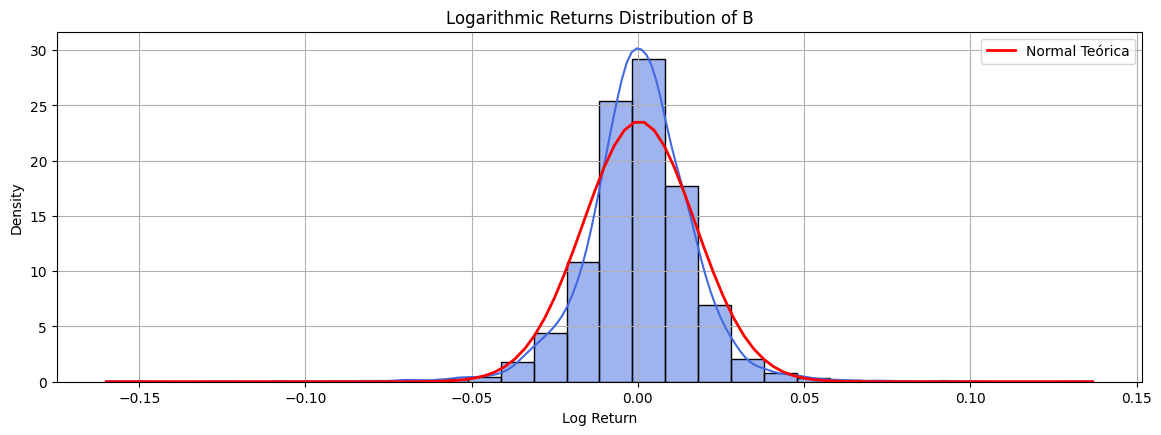

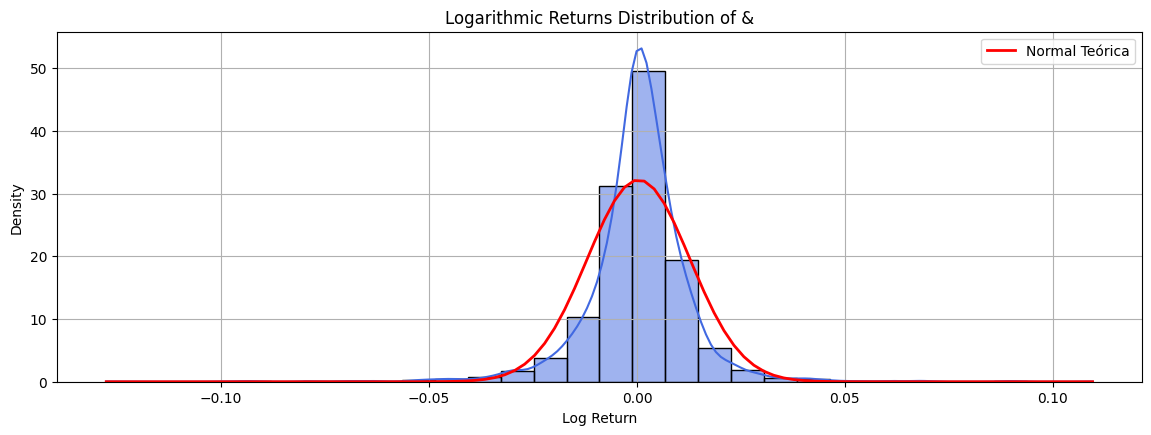

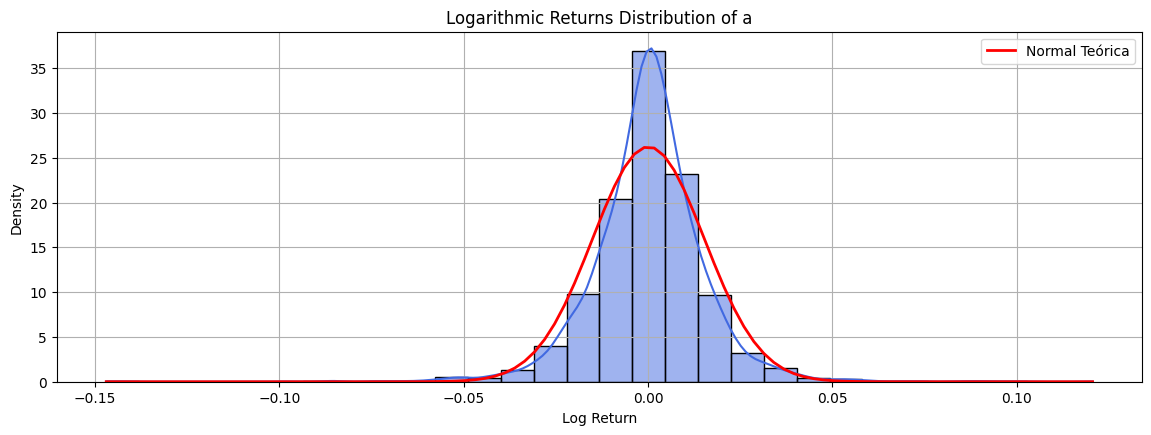

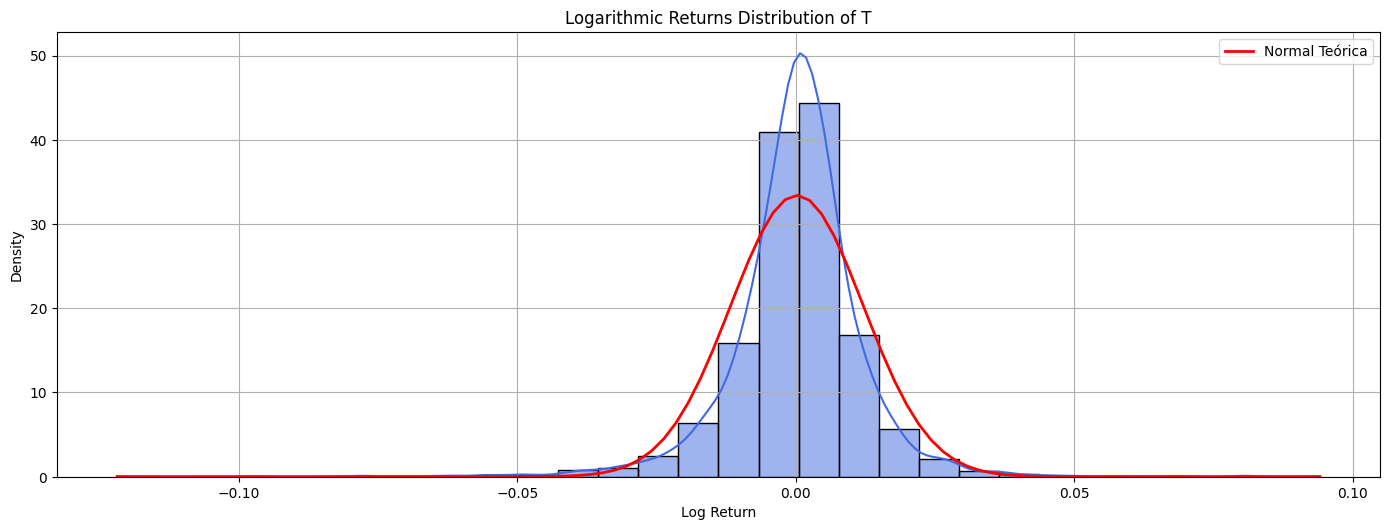

In [3]:
# --- Statistical Analysis of Log Returns ---

stats_df = pd.DataFrame({
    'Mean': log_market_returns.mean(),
    'Variance': log_market_returns.var(),
    'Std Dev': log_market_returns.std(),
    'Skewness': log_market_returns.skew(),
    'Kurtosis': log_market_returns.kurt()
})

display(stats_df)

for i in log_market_returns.columns:
    plt.figure(figsize=(14, 10))
    plt.subplot(2, 1, 1)
    sns.histplot(log_market_returns[i], kde=True, color='royalblue', bins=30, stat="density")

    mu, std = stats.norm.fit(log_market_returns[i])
    x = np.linspace(log_market_returns[i].min(), log_market_returns[i].max(), 100)
    p = stats.norm.pdf(x, mu, std)
    plt.plot(x, p, 'r', linewidth=2, label='Normal Teórica')
    
    plt.title(f'Logarithmic Returns Distribution of {i[1]}')
    plt.xlabel('Log Return')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# --- Test for Normality, Stacionarity and Heteroscedasticity ---

from scipy.stats import kstest, norm, probplot
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

test_results = [] 

for column in log_market_returns.columns:
    série = log_market_returns[column]

    série_padronizada = (série - série.mean()) / série.std()
    ks_stat, ks_p_value = kstest(série_padronizada, 'norm')

    adf_stat, adf_p_value, _, _, _, _ = adfuller(série)
    arch_stat, arch_p_value, _, _ = het_arch(série)

    test_results.append({
        'Index': column,  
        'KS p-value': ks_p_value,
        'ADF p-value': adf_p_value,
        'ARCH p-value': arch_p_value
    })

df_test_results = pd.DataFrame(test_results)
print('Test Results for Normality, Stationarity and Heteroscedasticity:')
display(df_test_results)

# Statistical Interpretation:
# KS < 0.05: Series not normal (Justifies the Extreme Value Theory).
# ADF < 0.05: Series are stationary (Safe for temporal modeling).
# ARCH-LM < 0.05: There is volatility clustering (Justifies GARCH).

Test Results for Normality, Stationarity and Heteroscedasticity:


,Index,KS p-value,ADF p-value,ARCH p-value
0,IBOVESPA,4.077731e-17,0.000000e+00,0.000000e+00
1,S&P 500,2.337494e-48,0.000000e+00,0.000000e+00
2,Hang Seng,5.480115e-18,1.564379e-28,1.526720e-92
3,STOXX 600,3.432462e-33,2.469560e-30,1.945606e-181


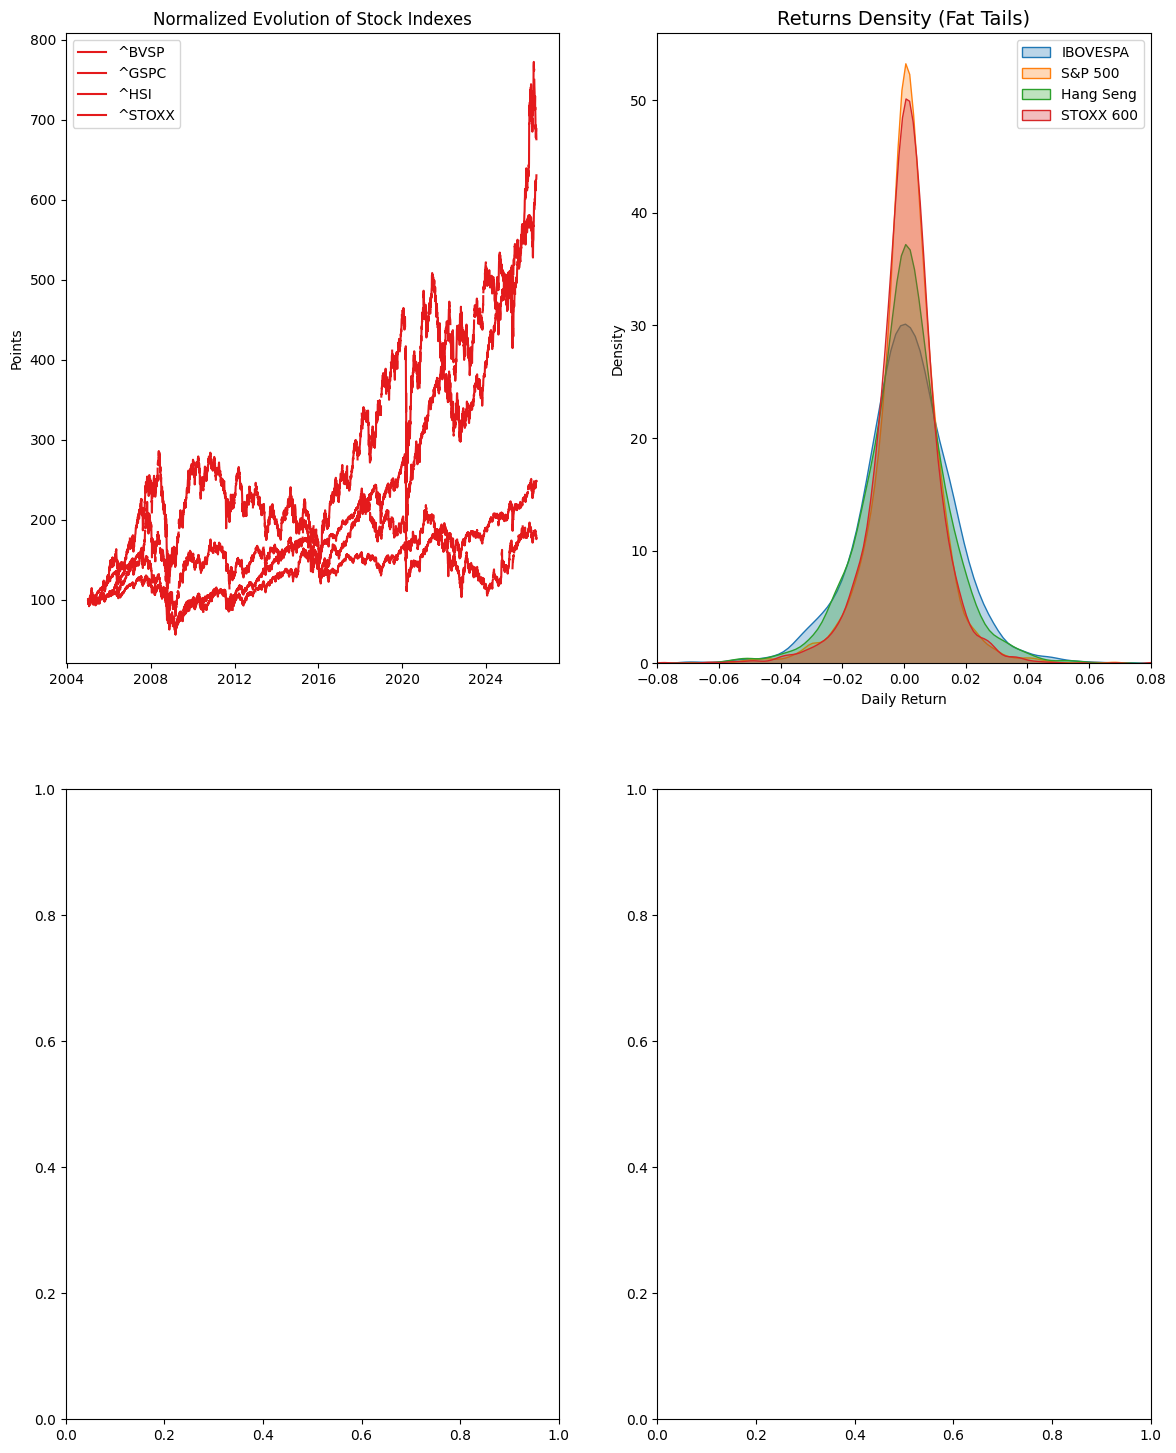

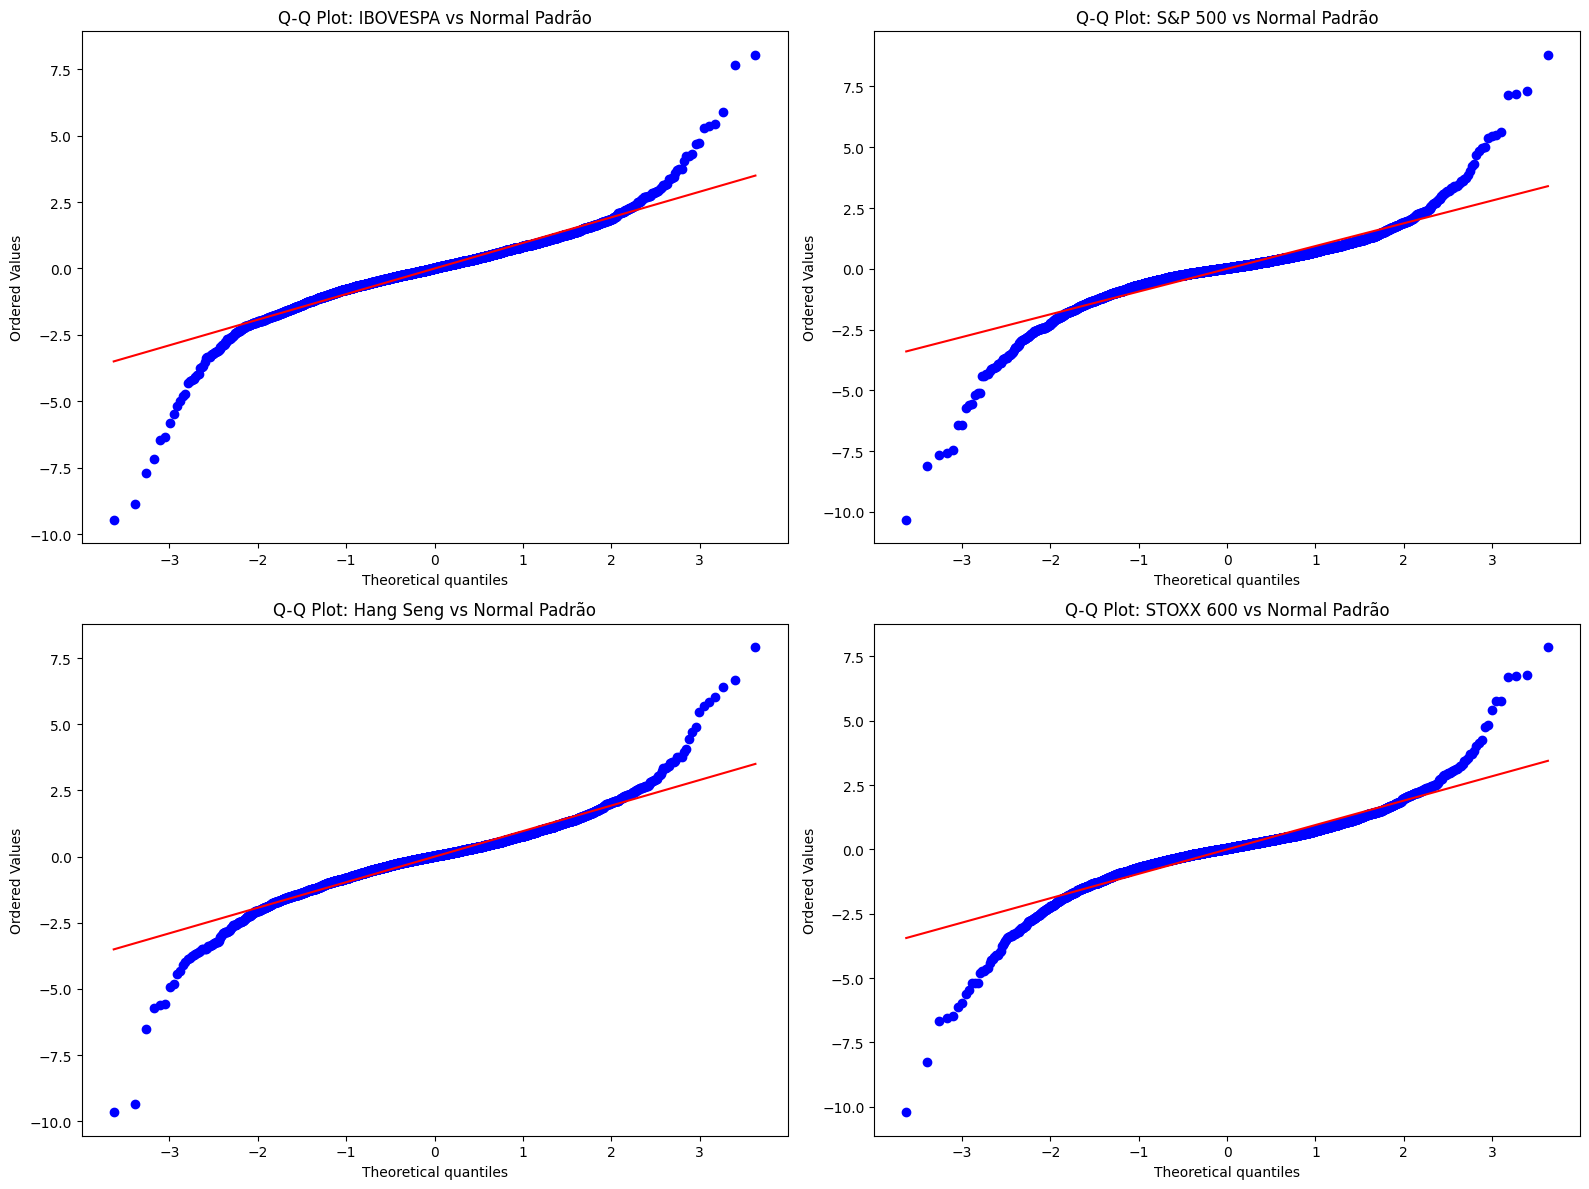

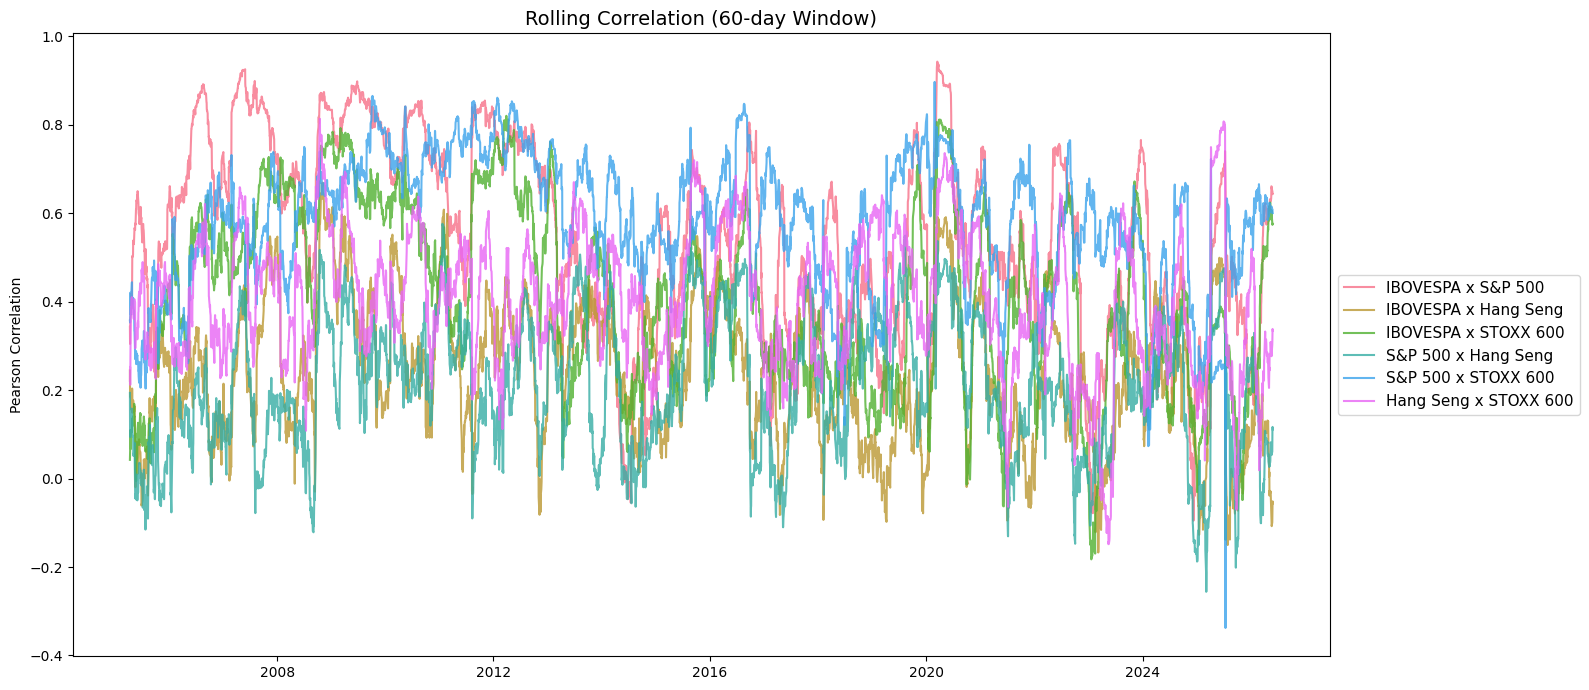

In [5]:
# --- Plotting Statistical Tests ---

import itertools 

fig, axes = plt.subplots(2, 2, figsize=(14,18))

normalized_prices = (raw_data / raw_data.iloc[0]) * 100
for col in normalized_prices.columns:
    axes[0,0].plot(normalized_prices.index, normalized_prices[col], label=col, color=plt.cm.Set1(0))
axes[0,0].set_title('Normalized Evolution of Stock Indexes')
axes[0,0].set_ylabel('Points')
axes[0,0].legend()

for col in log_market_returns.columns:
    sns.kdeplot(log_market_returns[col], ax=axes[0, 1], label=col, fill=True, alpha=0.3)
axes[0, 1].set_title('Returns Density (Fat Tails)', fontsize=14)
axes[0, 1].set_xlim(-0.08, 0.08) 
axes[0, 1].set_xlabel('Daily Return')
axes[0, 1].legend()

# --- QQ Plot for Indexes --- 
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
axes2 = axes2.flatten()

for i, col in enumerate(log_market_returns.columns):
    # Standardization of the series to compare with the Normal distribution (Mean 0, Std Dev 1)
    standardize_series = (log_market_returns[col] - log_market_returns[col].mean()) / log_market_returns[col].std()
    
    # probplot usa automaticamente o axes2[i] através do parâmetro 'plot'
    probplot(standardize_series, dist="norm", plot=axes2[i])
    
    axes2[i].set_title(f'Q-Q Plot: {col} vs Normal Padrão', fontsize=12)
    axes2[i].get_lines()[0].set_markerfacecolor('blue')
    axes2[i].get_lines()[0].set_markeredgecolor('blue')

plt.tight_layout()
plt.show()

# --- Correlation Analysis ---

fig3, ax3 = plt.subplots(figsize=(16,7))

window = 60
indexes = log_market_returns.columns
combinations = list(itertools.combinations(indexes, 2))
colors = sns.color_palette('husl', len(combinations))

for i, (col1, col2) in enumerate(combinations):
    rolling_corr = log_market_returns[col1].rolling(window).corr(log_market_returns[col2])
    ax3.plot(rolling_corr.index, rolling_corr, label=f'{col1} x {col2}', color=colors[i], alpha=0.8)
ax3.set_title('Rolling Correlation (60-day Window)', fontsize=14)
ax3.set_ylabel('Pearson Correlation')
ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)
plt.tight_layout()
plt.show()


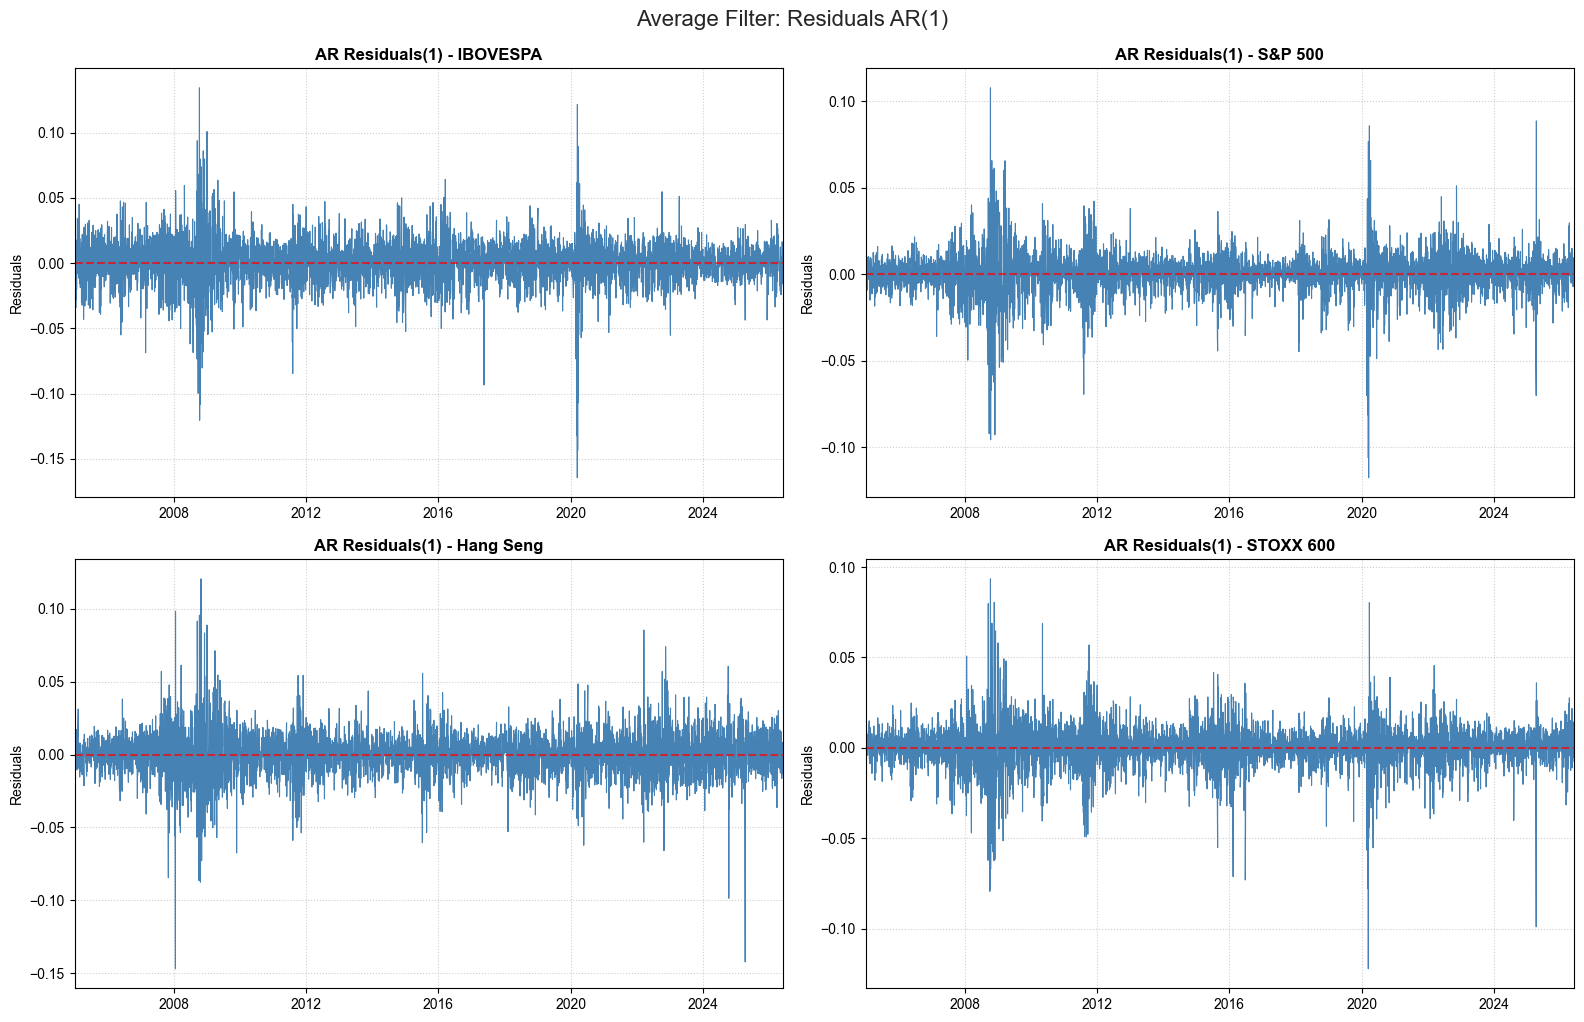

In [6]:
# --- ARIMA/SARIMA Modeling for IBOVESPA Index ---
import warnings
from statsmodels.tsa.arima.model import ARIMA

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# --- Creating a new DataFrame to store the data ---
ar_residuals = pd.DataFrame(index=log_market_returns.index)

for col in log_market_returns.columns:
    ar_model = ARIMA(log_market_returns[col].dropna(), order=(1, 0, 0))
    ar_result = ar_model.fit()
    ar_residuals[col] = ar_result.resid

# --- Model EGARCH will model a clean data series ---

for i, col in enumerate(ar_residuals.columns):
    axes[i].plot(ar_residuals.index, ar_residuals[col], color='steelblue', linewidth=0.8)
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.7)
    
    axes[i].set_title(f'AR Residuals(1) - {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Residuals')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    axes[i].set_xlim(ar_residuals.index.min(), ar_residuals.index.max())

plt.tight_layout()
plt.suptitle('Average Filter: Residuals AR(1)', fontsize=16, y=1.02)
plt.show()


In [7]:
# --- GARCH Modeling for IBOVESPA Index ---

from arch import arch_model 
percentage_ar_residuals = ar_residuals * 100
model_garch_ibov = arch_model(percentage_ar_residuals['IBOVESPA'], vol='EGARCH', p=1, q=1, o=1, dist='normal', rescale=False)
result_ibov = model_garch_ibov.fit(update_freq=5)
print(result_ibov.summary())

conditional_volatility = result_ibov.conditional_volatility
standardized_residuals = result_ibov.resid / conditional_volatility
original_returns = percentage_ar_residuals['IBOVESPA']

Iteration:      5,   Func. Count:     49,   Neg. LLF: 13650.478532278588
Iteration:     10,   Func. Count:     84,   Neg. LLF: 8783.67490508833
Optimization terminated successfully    (Exit mode 0)
            Current function value: 8783.662753773264
            Iterations: 12
            Function evaluations: 97
            Gradient evaluations: 12
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:               IBOVESPA   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -8783.66
Distribution:                  Normal   AIC:                           17577.3
Method:            Maximum Likelihood   BIC:                           17609.8
                                        No. Observations:                 4881
Date:                Mon, Jun 29 2026   Df Residuals:                     4880
Time:          

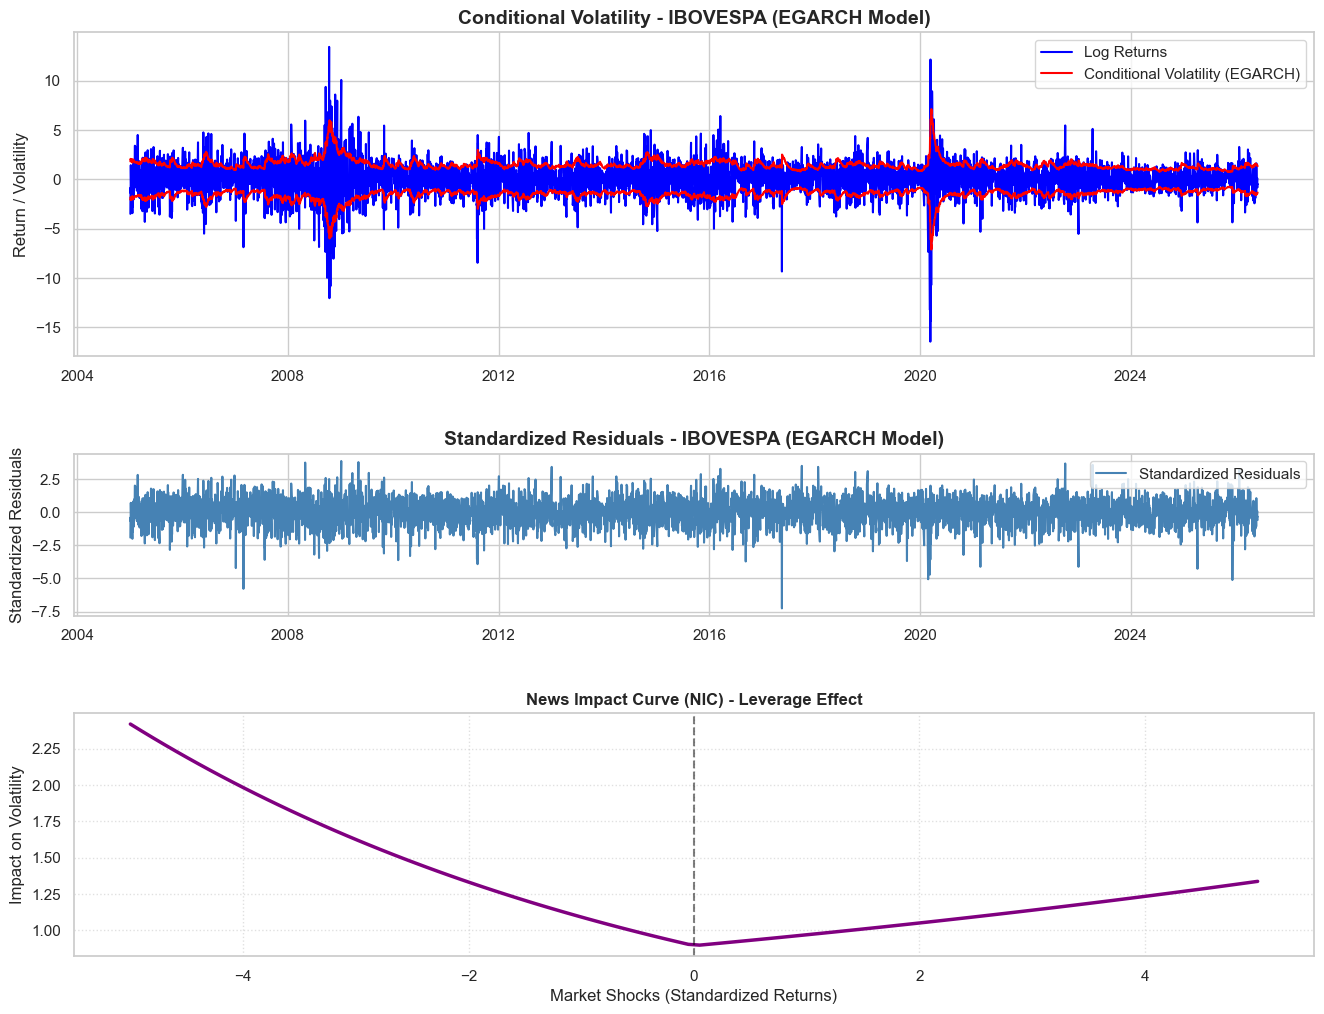

In [8]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1.5], hspace=0.4)

# --- Figure 1: Conditional Volatility ---

ax1 = fig.add_subplot(gs[0])
ax1.plot(original_returns.index, original_returns, label='Log Returns', color='blue')
ax1.plot(conditional_volatility.index, conditional_volatility, color='red', linewidth=1.5, label='Conditional Volatility (EGARCH)')
ax1.plot(conditional_volatility.index, -conditional_volatility, color='red', linewidth=1.5)
ax1.set_title('Conditional Volatility - IBOVESPA (EGARCH Model)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Return / Volatility')
ax1.legend(loc='upper right')

# --- Figure 2: Standardized Residuals ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(standardized_residuals.index, standardized_residuals, label='Standardized Residuals', color='steelblue')
ax2.set_title('Standardized Residuals - IBOVESPA (EGARCH Model)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Standardized Residuals')
ax2.legend(loc='upper right')

# --- Figure 3: New Impact Curve ---

ax3 = fig.add_subplot(gs[2])
params = result_ibov.params
omega = params['omega']
alpha = params['alpha[1]']
gamma = params['gamma[1]']  # Leverage effect of Stock Indexes

# Simulate a range of standardized schocks (z) to plot the impact curve

z_simulated = np.linspace(-5, 5, 100)
nic_log_var = alpha * (np.abs(z_simulated) - np.sqrt(2/np.pi)) + gamma * z_simulated
nic_vol = np.exp(nic_log_var)

ax3.plot(z_simulated, nic_vol, color='purple', linewidth=2.5)
ax3.axvline(0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('News Impact Curve (NIC) - Leverage Effect', fontsize=12, fontweight='bold')
ax3.set_xlabel('Market Shocks (Standardized Returns)')
ax3.set_ylabel('Impact on Volatility')
ax3.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [9]:
model_garch_sp500 = arch_model(percentage_ar_residuals['S&P 500'], vol='EGARCH', p=1, q=1, o=1, dist='normal')
result_sp500 = model_garch_sp500.fit(update_freq=5)
print(result_sp500.summary())

conditional_volatility_sp500 = result_sp500.conditional_volatility
standardized_residuals_sp500 = result_sp500.resid / conditional_volatility_sp500
original_returns_sp500 = percentage_ar_residuals['S&P 500']

Iteration:      5,   Func. Count:     48,   Neg. LLF: 28548.411584767375
Iteration:     10,   Func. Count:     80,   Neg. LLF: 6584.503218433752
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6584.503215172294
            Iterations: 12
            Function evaluations: 91
            Gradient evaluations: 12
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                S&P 500   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -6584.50
Distribution:                  Normal   AIC:                           13179.0
Method:            Maximum Likelihood   BIC:                           13211.5
                                        No. Observations:                 4881
Date:                Mon, Jun 29 2026   Df Residuals:                     4880
Time:         

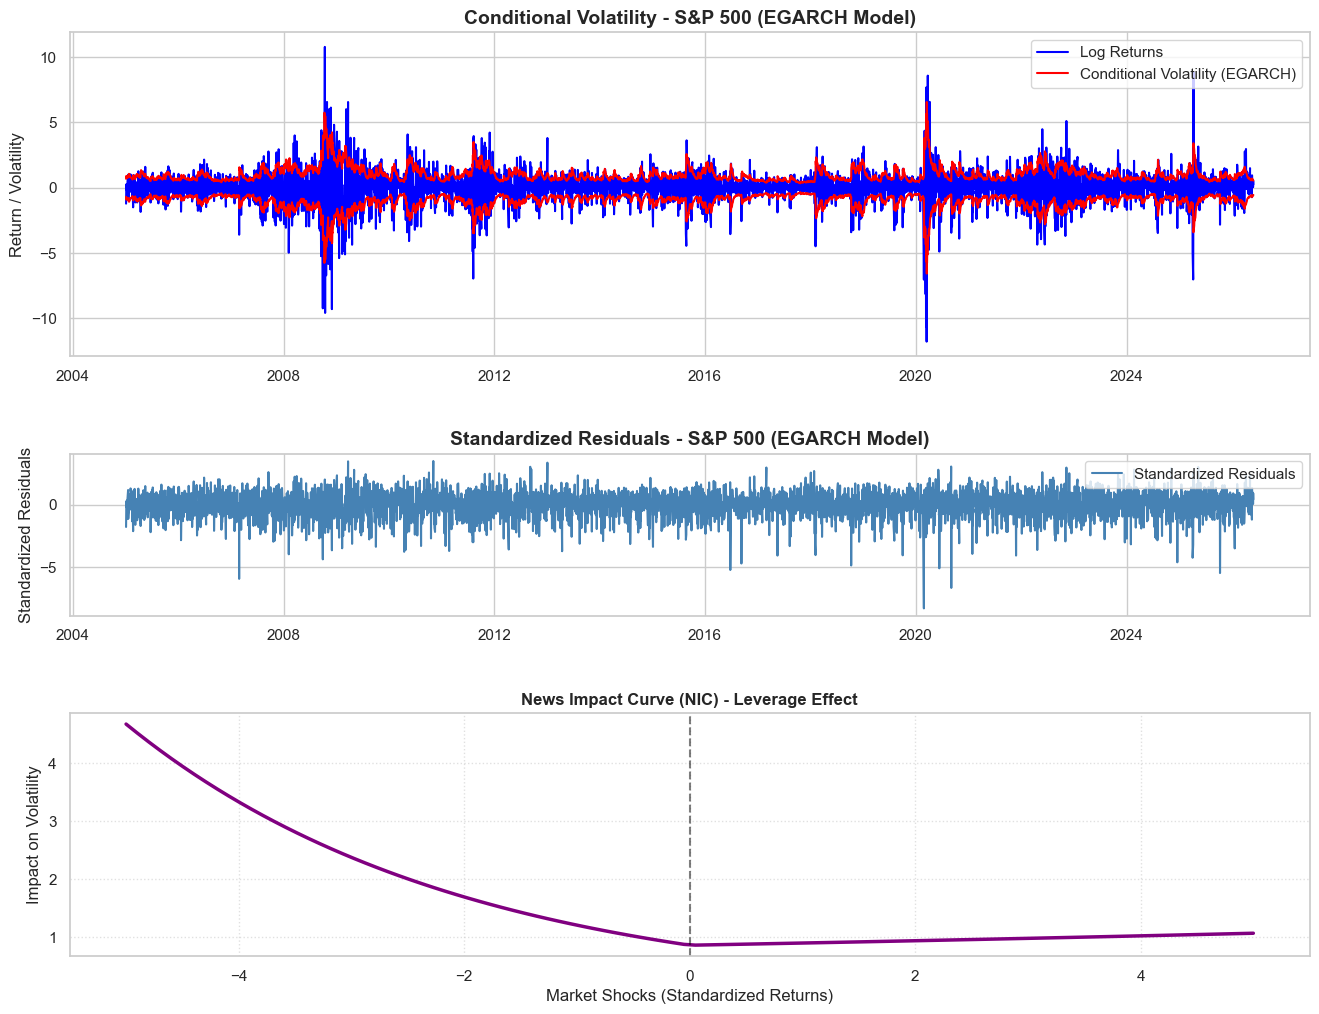

In [10]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1.5], hspace=0.4)

# --- Figure 1: Conditional Volatility ---

ax1 = fig.add_subplot(gs[0])
ax1.plot(original_returns_sp500.index, original_returns_sp500, label='Log Returns', color='blue')
ax1.plot(conditional_volatility_sp500.index, conditional_volatility_sp500, color='red', linewidth=1.5, label='Conditional Volatility (EGARCH)')
ax1.plot(conditional_volatility_sp500.index, -conditional_volatility_sp500, color='red', linewidth=1.5)
ax1.set_title('Conditional Volatility - S&P 500 (EGARCH Model)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Return / Volatility')
ax1.legend(loc='upper right')

# --- Figure 2: Standardized Residuals ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(standardized_residuals_sp500.index, standardized_residuals_sp500, label='Standardized Residuals', color='steelblue')
ax2.set_title('Standardized Residuals - S&P 500 (EGARCH Model)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Standardized Residuals')
ax2.legend(loc='upper right')

# --- Figure 3: New Impact Curve ---

ax3 = fig.add_subplot(gs[2])
params = result_sp500.params
omega = params['omega']
alpha = params['alpha[1]']
gamma = params['gamma[1]']  # Leverage effect of Stock Indexes

# Simulate a range of standardized schocks (z) to plot the impact curve

z_simulated_sp500 = np.linspace(-5, 5, 100)
nic_log_var = alpha * (np.abs(z_simulated_sp500) - np.sqrt(2/np.pi)) + gamma * z_simulated_sp500
nic_vol = np.exp(nic_log_var)

ax3.plot(z_simulated_sp500, nic_vol, color='purple', linewidth=2.5)
ax3.axvline(0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('News Impact Curve (NIC) - Leverage Effect', fontsize=12, fontweight='bold')
ax3.set_xlabel('Market Shocks (Standardized Returns)')
ax3.set_ylabel('Impact on Volatility')
ax3.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [11]:
model_garch_hang_seng = arch_model(percentage_ar_residuals['Hang Seng'], vol='EGARCH', p=1, q=1, o=1, dist='normal')
result_hang_seng = model_garch_hang_seng.fit(update_freq=5)
print(result_hang_seng.summary())

conditional_volatility_hang_seng = result_hang_seng.conditional_volatility
standardized_residuals_hang_seng = result_hang_seng.resid / conditional_volatility_hang_seng
original_returns_hang_seng = percentage_ar_residuals['Hang Seng']

Iteration:      5,   Func. Count:     52,   Neg. LLF: 8307.732584428632
Iteration:     10,   Func. Count:     87,   Neg. LLF: 8259.375457318112
Optimization terminated successfully    (Exit mode 0)
            Current function value: 8259.375455867375
            Iterations: 12
            Function evaluations: 98
            Gradient evaluations: 12
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:              Hang Seng   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -8259.38
Distribution:                  Normal   AIC:                           16528.8
Method:            Maximum Likelihood   BIC:                           16561.2
                                        No. Observations:                 4881
Date:                Mon, Jun 29 2026   Df Residuals:                     4880
Time:          

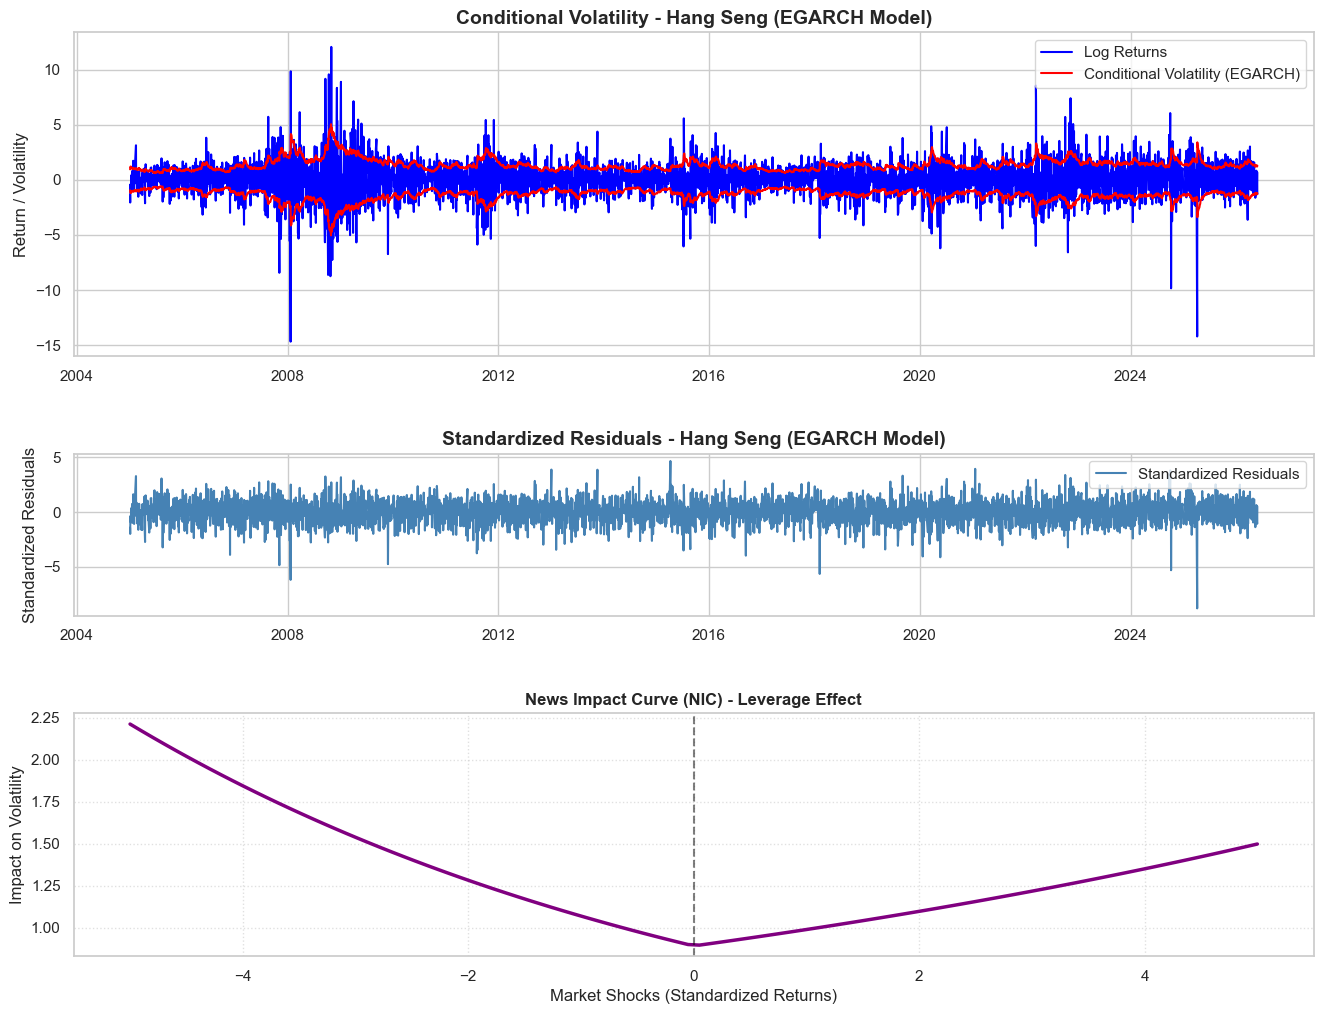

In [12]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1.5], hspace=0.4)

# --- Figure 1: Conditional Volatility ---

ax1 = fig.add_subplot(gs[0])
ax1.plot(original_returns_hang_seng.index, original_returns_hang_seng, label='Log Returns', color='blue')
ax1.plot(conditional_volatility_hang_seng.index, conditional_volatility_hang_seng, color='red', linewidth=1.5, label='Conditional Volatility (EGARCH)')
ax1.plot(conditional_volatility_hang_seng.index, -conditional_volatility_hang_seng, color='red', linewidth=1.5)
ax1.set_title('Conditional Volatility - Hang Seng (EGARCH Model)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Return / Volatility')
ax1.legend(loc='upper right')

# --- Figure 2: Standardized Residuals ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(standardized_residuals_hang_seng.index, standardized_residuals_hang_seng, label='Standardized Residuals', color='steelblue')
ax2.set_title('Standardized Residuals - Hang Seng (EGARCH Model)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Standardized Residuals')
ax2.legend(loc='upper right')

# --- Figure 3: New Impact Curve ---

ax3 = fig.add_subplot(gs[2])
params = result_hang_seng.params
omega = params['omega']
alpha = params['alpha[1]']
gamma = params['gamma[1]']  # Leverage effect of Stock Indexes

# Simulate a range of standardized schocks (z) to plot the impact curve

z_simulated_hang_seng = np.linspace(-5, 5, 100)
nic_log_var = alpha * (np.abs(z_simulated_hang_seng) - np.sqrt(2/np.pi)) + gamma * z_simulated_hang_seng
nic_vol = np.exp(nic_log_var)

ax3.plot(z_simulated_hang_seng, nic_vol, color='purple', linewidth=2.5)
ax3.axvline(0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('News Impact Curve (NIC) - Leverage Effect', fontsize=12, fontweight='bold')
ax3.set_xlabel('Market Shocks (Standardized Returns)')
ax3.set_ylabel('Impact on Volatility')
ax3.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [13]:
model_garch_Stoxx = arch_model(percentage_ar_residuals['STOXX 600'], vol='EGARCH', p=1, q=1, o=1, dist='normal')
result_stoxx = model_garch_Stoxx.fit(update_freq=5)
print(result_stoxx.summary())

conditional_volatility_stoxx = result_stoxx.conditional_volatility
standardized_residuals_stoxx = result_stoxx.resid / conditional_volatility_stoxx
original_returns_stoxx = percentage_ar_residuals['STOXX 600']

Iteration:      5,   Func. Count:     49,   Neg. LLF: 26150.13308850708
Iteration:     10,   Func. Count:     82,   Neg. LLF: 6673.837227731042
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6673.837065866862
            Iterations: 14
            Function evaluations: 105
            Gradient evaluations: 14
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:              STOXX 600   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -6673.84
Distribution:                  Normal   AIC:                           13357.7
Method:            Maximum Likelihood   BIC:                           13390.1
                                        No. Observations:                 4881
Date:                Mon, Jun 29 2026   Df Residuals:                     4880
Time:         

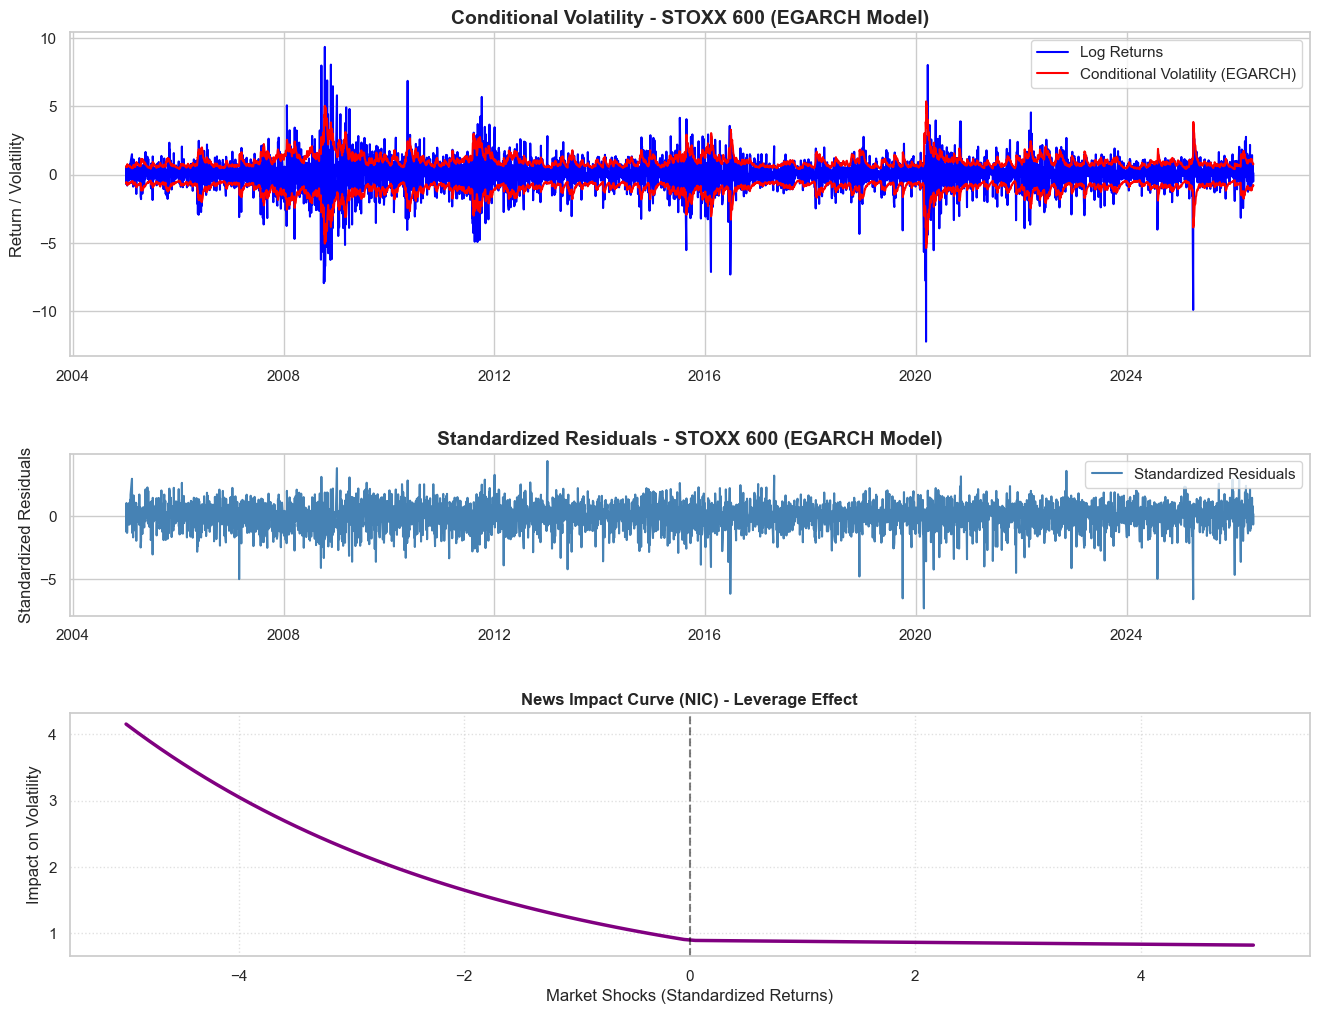

In [14]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1.5], hspace=0.4)

# --- Figure 1: Conditional Volatility ---

ax1 = fig.add_subplot(gs[0])
ax1.plot(original_returns_stoxx.index, original_returns_stoxx, label='Log Returns', color='blue')
ax1.plot(conditional_volatility_stoxx.index, conditional_volatility_stoxx, color='red', linewidth=1.5, label='Conditional Volatility (EGARCH)')
ax1.plot(conditional_volatility_stoxx.index, -conditional_volatility_stoxx, color='red', linewidth=1.5)
ax1.set_title('Conditional Volatility - STOXX 600 (EGARCH Model)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Return / Volatility')
ax1.legend(loc='upper right')

# --- Figure 2: Standardized Residuals ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(standardized_residuals_stoxx.index, standardized_residuals_stoxx, label='Standardized Residuals', color='steelblue')
ax2.set_title('Standardized Residuals - STOXX 600 (EGARCH Model)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Standardized Residuals')
ax2.legend(loc='upper right')

# --- Figure 3: New Impact Curve ---

ax3 = fig.add_subplot(gs[2])
params = result_stoxx.params
omega = params['omega']
alpha = params['alpha[1]']
gamma = params['gamma[1]']  # Leverage effect of Stock Indexes

# Simulate a range of standardized schocks (z) to plot the impact curve

z_simulated_stoxx = np.linspace(-5, 5, 100)
nic_log_var = alpha * (np.abs(z_simulated_stoxx) - np.sqrt(2/np.pi)) + gamma * z_simulated_stoxx
nic_vol = np.exp(nic_log_var)

ax3.plot(z_simulated_stoxx, nic_vol, color='purple', linewidth=2.5)
ax3.axvline(0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('News Impact Curve (NIC) - Leverage Effect', fontsize=12, fontweight='bold')
ax3.set_xlabel('Market Shocks (Standardized Returns)')
ax3.set_ylabel('Impact on Volatility')
ax3.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [15]:
from scipy.stats import kstest, norm, uniform
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

std_residuals = pd.DataFrame({
    'IBOVESPA': result_ibov.resid / result_ibov.conditional_volatility,
    'S&P 500': result_sp500.resid / result_sp500.conditional_volatility,
    'Hang Seng': result_hang_seng.resid / result_hang_seng.conditional_volatility,
    'STOXX 600': result_stoxx.resid / result_stoxx.conditional_volatility
}).astype(float).dropna()

# --- Applying Statistical Tests on the Standardized Residuals ---
print("Standardized Residuals Diagnosis:")
diag_results = {}
for i, col in enumerate(std_residuals.columns):
    serie = std_residuals[col].to_numpy(dtype=float)
    
    # Autocorrelation Test
    lb_df = acorr_ljungbox(serie, lags=[10], return_df=True)
    lb_pval = float(lb_df.iloc[0, 1])
    
    # Heteroscedasticity Test
    _, arch_pval, _, _ = het_arch(serie, nlags=10)
    
    # Normality Test (KS)
    _, ks_pval = kstest(serie, 'norm', args=(serie.mean(), serie.std()))
    
    diag_results[col] = (lb_pval, arch_pval, ks_pval)

diag_df = pd.DataFrame(diag_results, index=['Ljung-Box P-value', 'ARCH-LM P-value', 'KS P-value']).T
display(diag_df.round(4))

print("Interpretation:")
print("- Ljung-Box p-value < 0.05: Presence of autocorrelation in residuals (Model may not capture all dynamics).")
print("- ARCH p-value < 0.05: Presence of heteroscedasticity (Model may not fully capture volatility clustering).")
print("- KS p-value < 0.05: Residuals do not follow a normal distribution (Model may not capture fat tails).")

Standardized Residuals Diagnosis:


,Ljung-Box P-value,ARCH-LM P-value,KS P-value
IBOVESPA,0.3848,0.2132,0.0007
S&P 500,0.0033,0.7360,0.0000
Hang Seng,0.2981,0.5485,0.0000
STOXX 600,0.4049,0.3965,0.0000


Interpretation:
- Ljung-Box p-value < 0.05: Presence of autocorrelation in residuals (Model may not capture all dynamics).
- ARCH p-value < 0.05: Presence of heteroscedasticity (Model may not fully capture volatility clustering).
- KS p-value < 0.05: Residuals do not follow a normal distribution (Model may not capture fat tails).


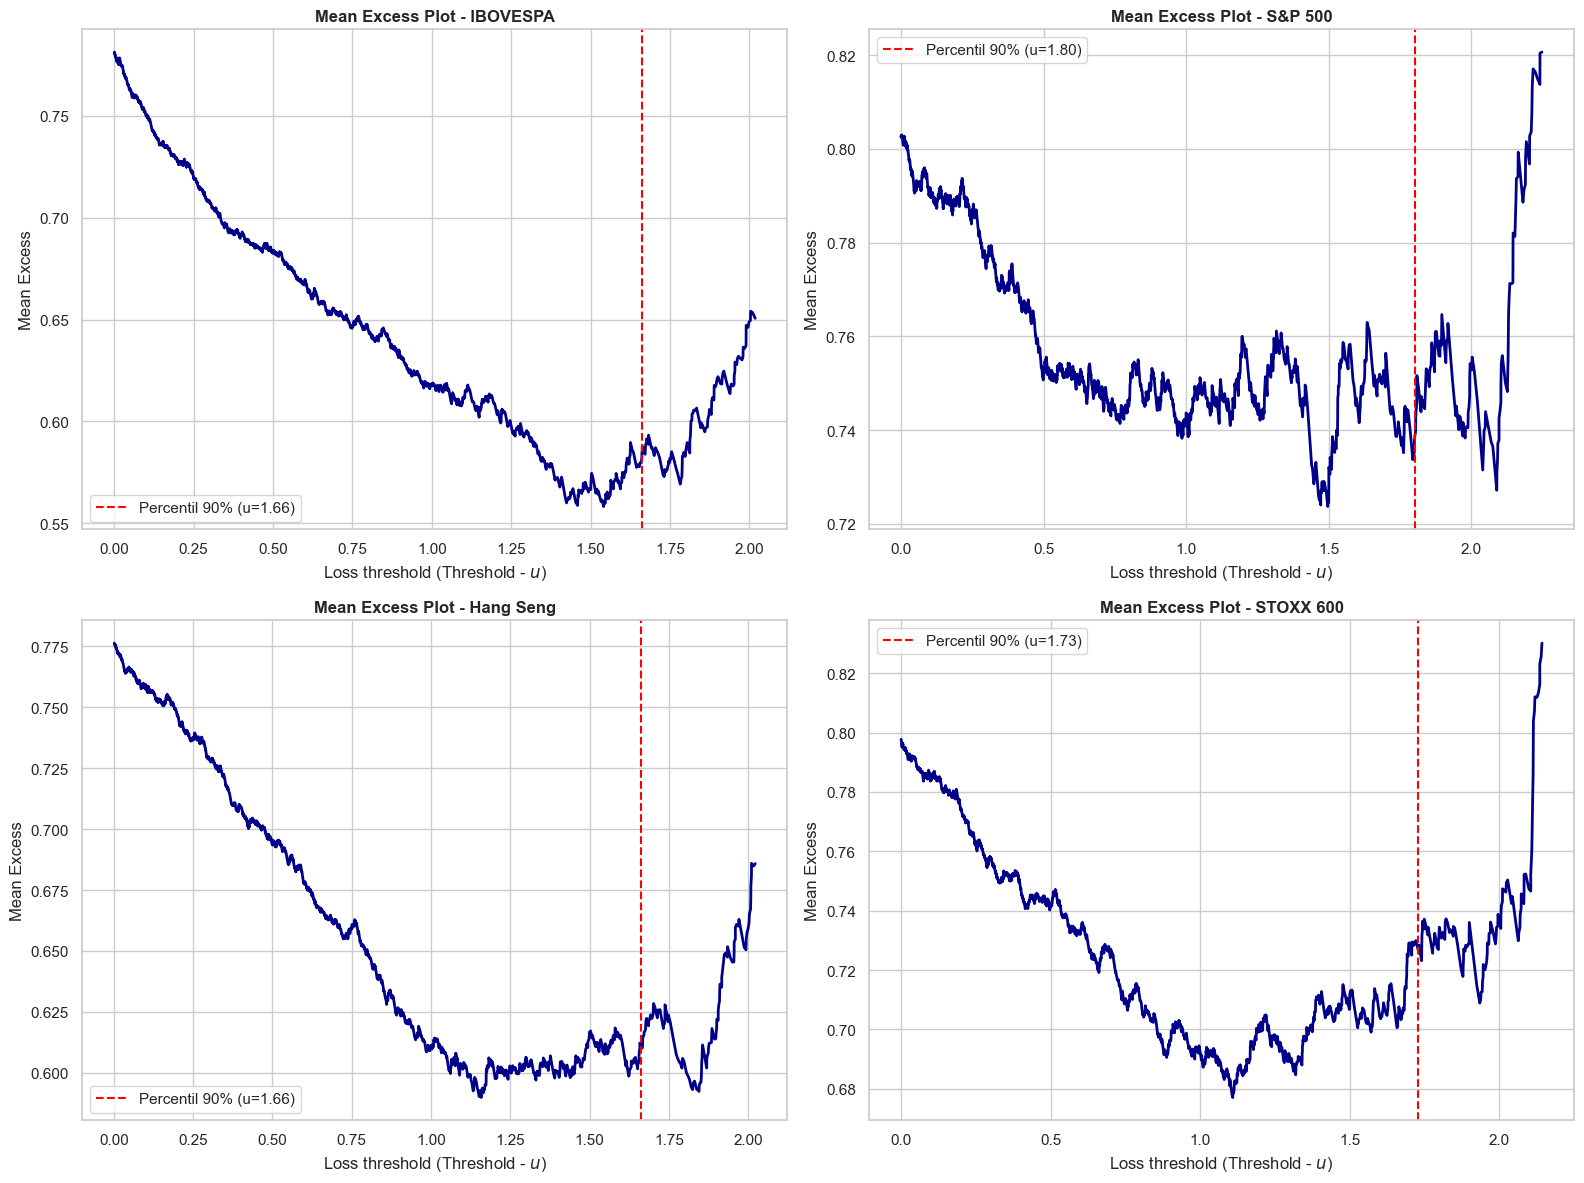

In [16]:
# --- Mean Excess Plot ---
# Preparing data for EVT

fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.flatten()

def calculate_mean_excess(data):
    data_sorted = np.sort(data)
    cut = max(1, int(len(data_sorted) * 0.05)) 
    thresholds = data_sorted[:-cut]

    mean_excess = [np.mean(data_sorted[data_sorted > u] - u) for u in thresholds]
    return thresholds, mean_excess

for i, col_name in enumerate(std_residuals.columns):
    col_str = str(col_name).replace("('Close', ", "").replace(")", "").replace("'", "").strip()
    
    column_data = std_residuals.iloc[:, i].dropna().to_numpy(dtype=float)
    perdas = -column_data[column_data < 0]
    
    thresholds, mean_excess = calculate_mean_excess(perdas)
    
    axes[i].plot(thresholds, mean_excess, color='darkblue', linewidth=2)
    axes[i].set_title(f'Mean Excess Plot - {col_str}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Loss threshold (Threshold - $u$)')
    axes[i].set_ylabel('Mean Excess')
    
    u_90 = np.percentile(perdas, 90)
    axes[i].axvline(u_90, color='red', linestyle='--', label=f'Percentil 90% (u={u_90:.2f})')
    axes[i].legend()

plt.tight_layout()
plt.show()
    

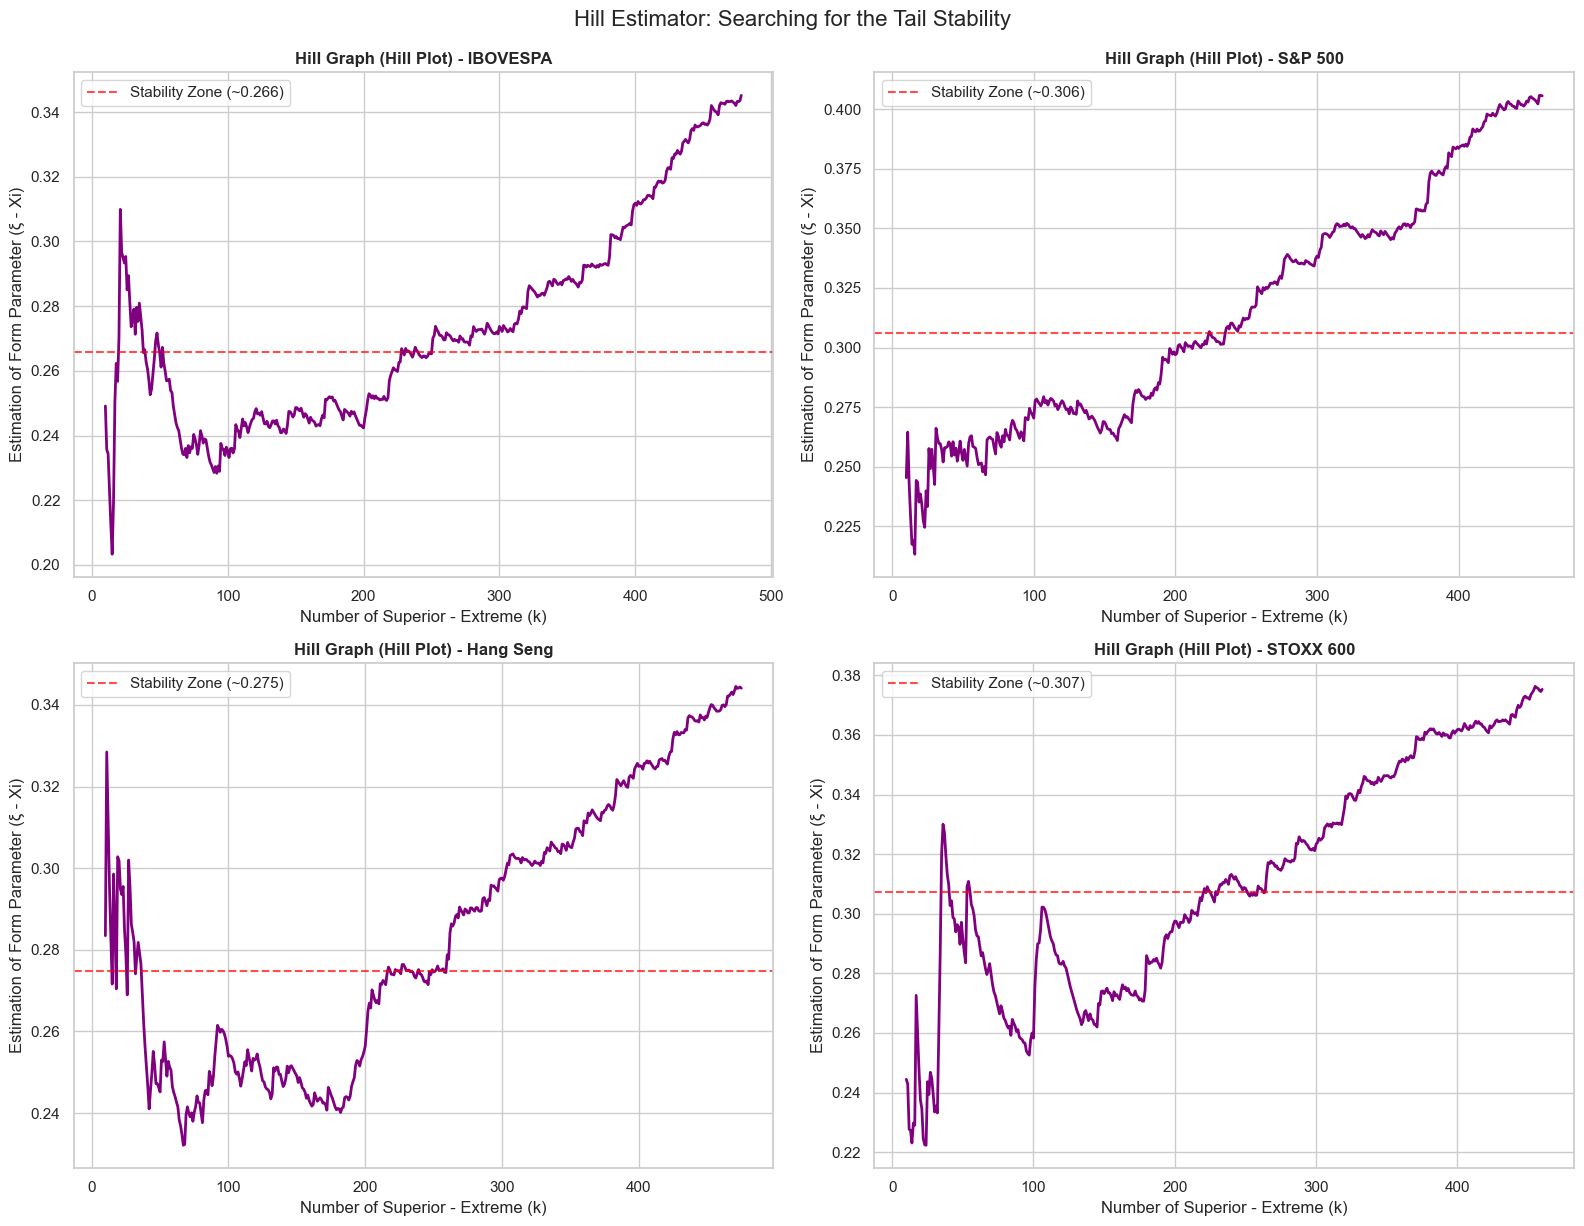

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

def estimator_hill(dados):
    """Calculate the Hill Estimator for K values."""
    # Ordenate from the largest to smallest
    Y = np.sort(dados)[::-1]
    n = len(Y)
    
    xi_valores = []
    # Test K (Data on the Tail) for 10% or 20% of the sample
    k_range = range(10, int(n * 0.20)) 
    
    for k in k_range:
        # Mathematics behind the Hill Estimator
        log_Y_k = np.log(Y[:k])
        log_Y_threshold = np.log(Y[k])
        xi = np.mean(log_Y_k - log_Y_threshold)
        xi_valores.append(xi)
        
    return list(k_range), xi_valores

for i, col in enumerate(std_residuals.columns): # Assuming std_residuals from the EGARCH
    col_str = str(col).replace("('Close', ", "").replace(")", "").replace("'", "").strip()
    
    # Loss's Filter (Left tail risk)
    data_columns = std_residuals.iloc[:, i].dropna().to_numpy(dtype=float)
    perdas = -data_columns[data_columns < 0]
    
    k_vals, xi_vals = estimator_hill(perdas)
    
    # Plotagem
    axes[i].plot(k_vals, xi_vals, color='purple', linewidth=2)
    axes[i].set_title(f'Hill Graph (Hill Plot) - {col_str}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Number of Superior - Extreme (k)')
    axes[i].set_ylabel('Estimation of Form Parameter (ξ - Xi)')
    
    # A linha horizontal marca uma "zona de estabilidade" visual
    stability_zone = np.median(xi_vals[len(xi_vals)//3 : 2*len(xi_vals)//3])
    axes[i].axhline(stability_zone, color='red', linestyle='--', alpha=0.7, label=f'Stability Zone (~{stability_zone:.3f})')
    axes[i].legend()

plt.tight_layout()
plt.suptitle('Hill Estimator: Searching for the Tail Stability', fontsize=16, y=1.02)
plt.show()

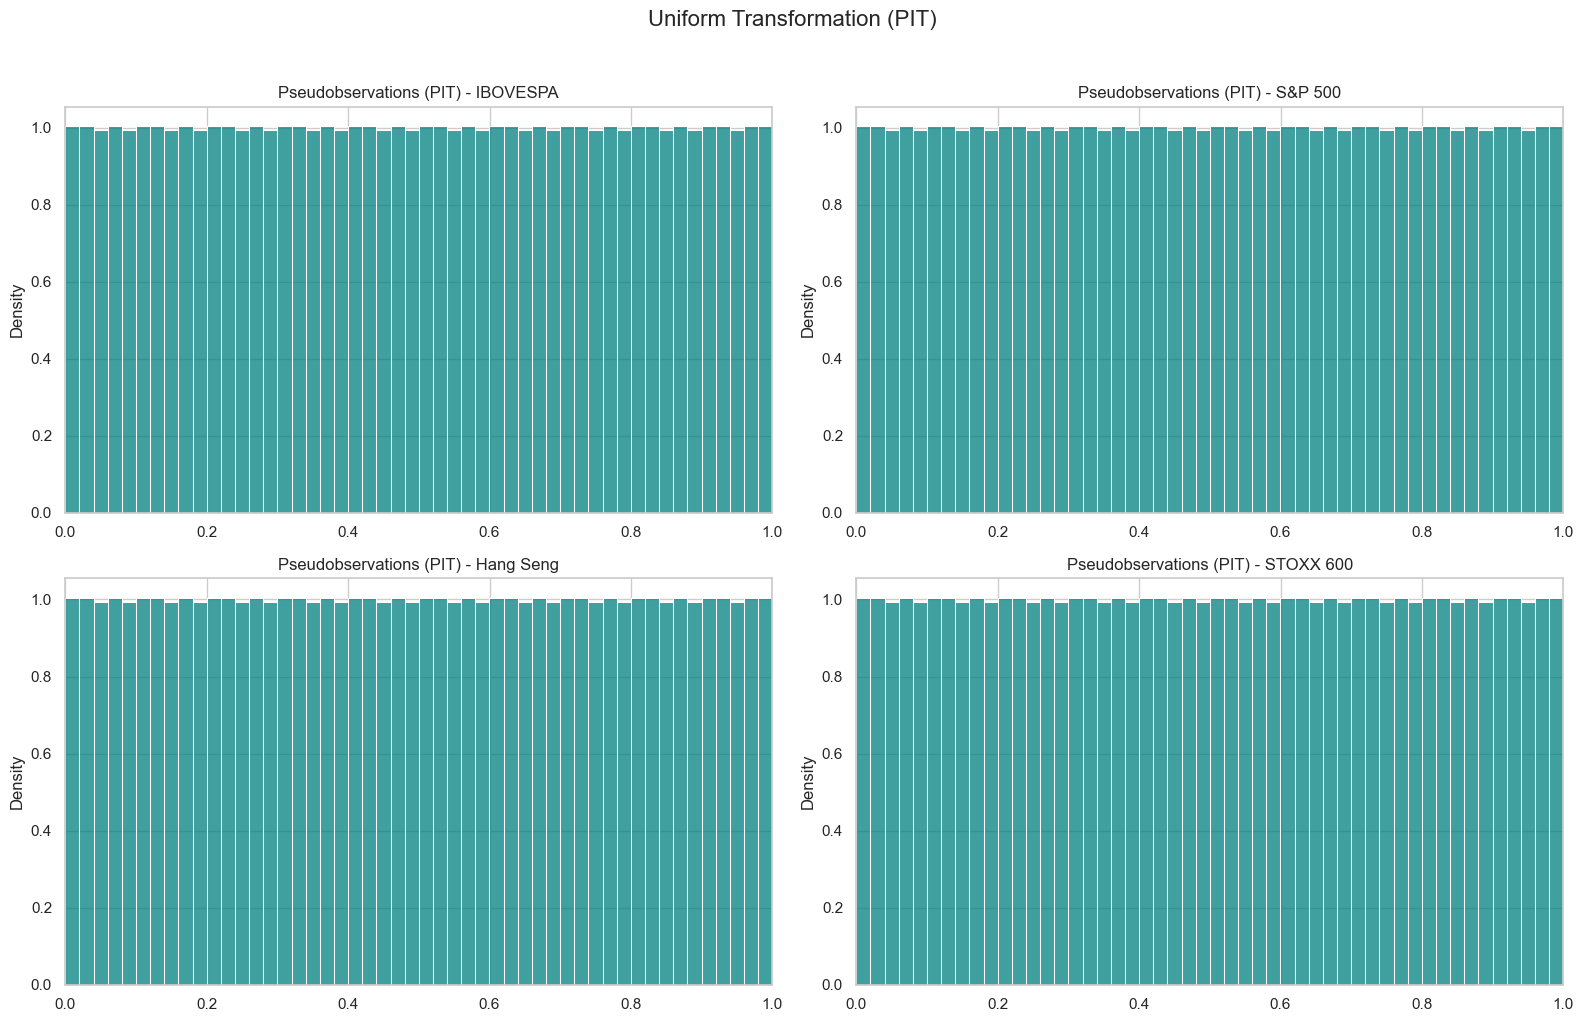

In [18]:
# ---  PROBABILITY INTEGRAL TRANSFORM (PIT) ---
# ==============================================

pseudo_observations = std_residuals.rank(method='average') / (len(std_residuals) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col_name in enumerate(pseudo_observations.columns):
    col_str = str(col_name).replace("('Close', ", "").replace(")", "").replace("'", "").strip()
    
    uniform_data = pseudo_observations.iloc[:, i].dropna().to_numpy(dtype=float)
    
    sns.histplot(uniform_data, bins=50, ax=axes[i], color='teal', stat="density")
    axes[i].set_title(f'Pseudobservations (PIT) - {col_str}', fontsize=12)
    axes[i].set_xlim(0, 1)

plt.suptitle('Uniform Transformation (PIT)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Calculating VaR and CVaR before EVT and Copulas

Calculating VaR and CVaR for 99.0 of confidence



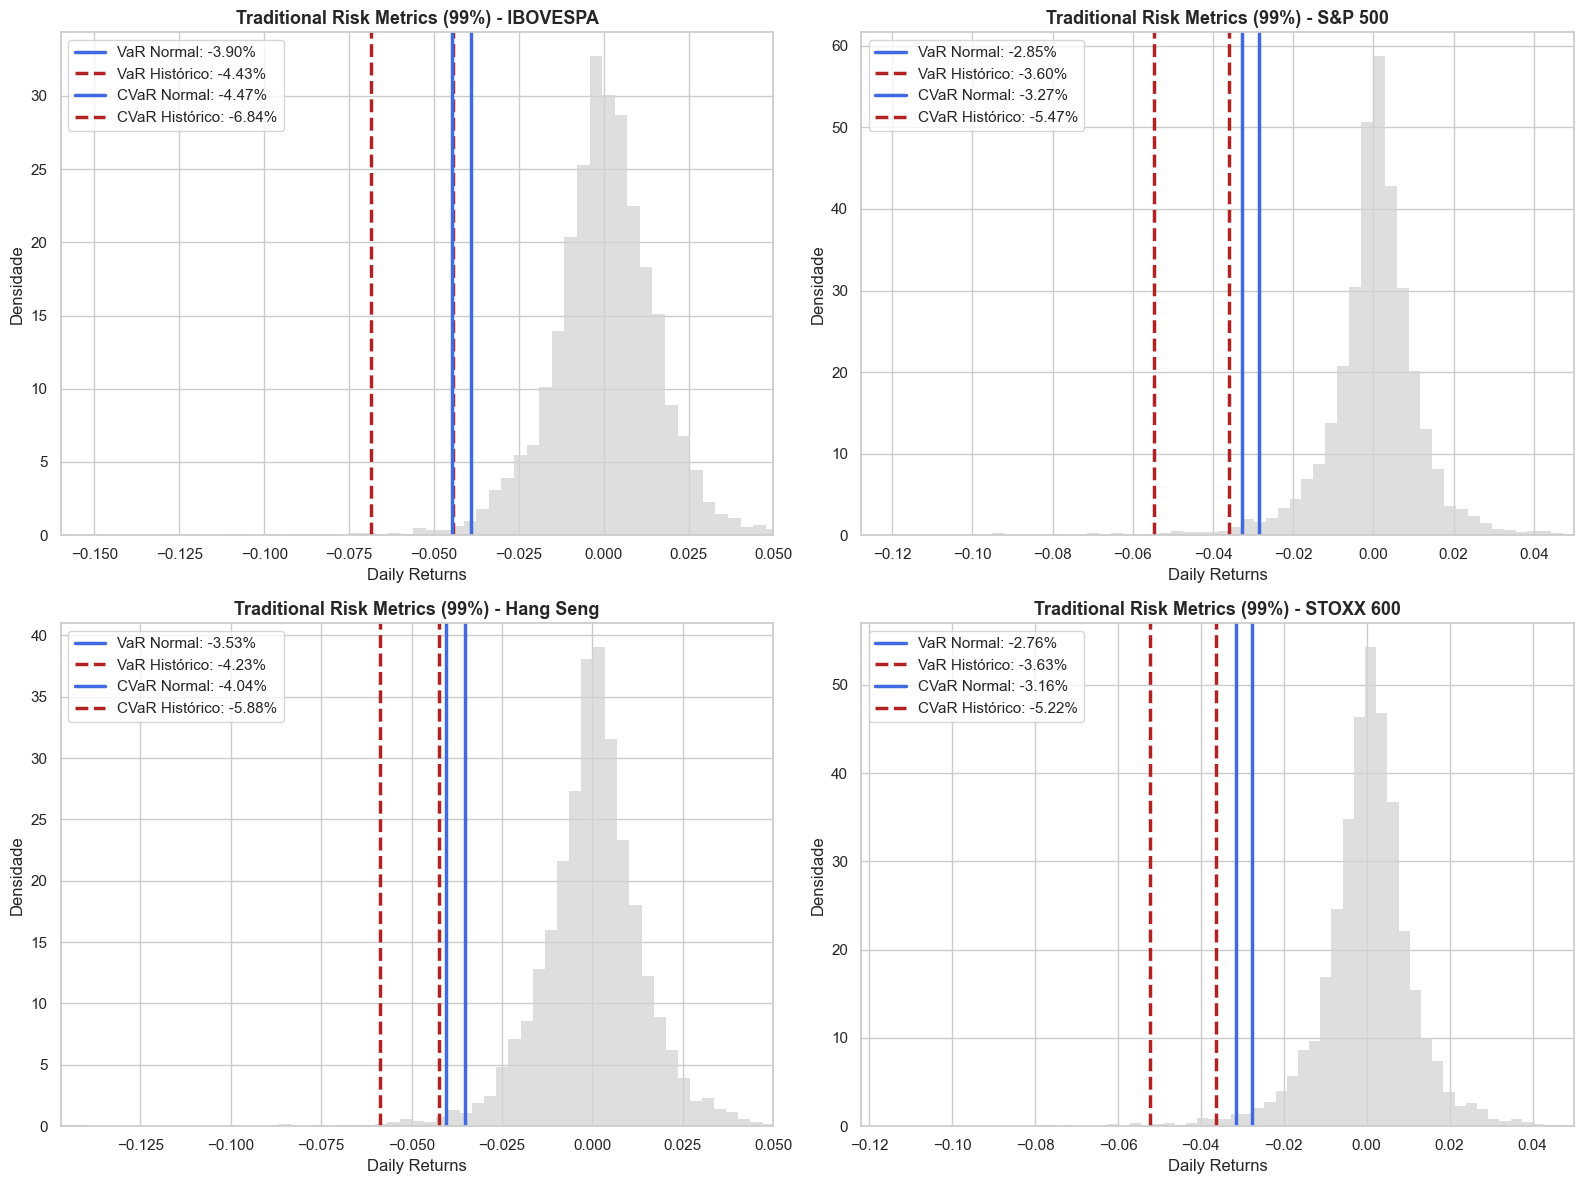

=== Table: VaR and CVaR (Tradicional) (Values in %) ===


,Normal VaR (99%),Normal CVaR (99%),Historical VaR (99%),Historical CVaR (99%)
Índice,,,,
IBOVESPA,-3.90,-4.47,-4.43,-6.84
S&P 500,-2.85,-3.27,-3.60,-5.47
Hang Seng,-3.53,-4.04,-4.23,-5.88
STOXX 600,-2.76,-3.16,-3.63,-5.22


In [19]:
sns.set_theme(style="whitegrid")

# As we are focusing in Extreme Values and Fat Tails, confidence interval of 99%

trust = 0.99
alpha = 1 - trust

risk_result = []

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

print(f"Calculating VaR and CVaR for {trust*100} of confidence\n")
for i, col in enumerate(log_market_returns.columns):
    ax = axes[i]
    returns = log_market_returns[col].dropna().to_numpy(dtype=float)

    # ======================================
    # --- VaR and CVaR (Parametric/Gaussian)
    # ======================================

    mu = np.mean(returns)
    sigma = np.std(returns, ddof=1)

    # Calculating the Z-Score:
    z_alpha = norm.ppf(alpha)

    parametric_var = mu + sigma * z_alpha
    parametric_cvar = mu - sigma * (norm.pdf(z_alpha) / alpha)

    # =============================
    # --- VaR and CVaR (Historical)
    # =============================

    historical_var = np.percentile(returns, alpha * 100)
    historical_cvar = np.mean(returns[returns <= historical_var])

    # =============================
    # --- Results in Dataframes ---
    # =============================
    risk_result.append({
        'Índice': col,
        'Normal VaR (99%)': parametric_var * 100,  # Multipplying by 100 to get a %
        'Normal CVaR (99%)': parametric_cvar * 100,
        'Historical VaR (99%)': historical_var * 100,
        'Historical CVaR (99%)': historical_cvar * 100
    })

    # ============
    # --- Plot ---
    # ============

    ax.clear()
    sns.histplot(x=returns, bins=80, ax=ax, color='lightgray', stat="density", edgecolor='none')
    
    # Linhas de Risco
    axes[i].axvline(parametric_var, color='royalblue', linestyle='-', linewidth=2.5, label=f'VaR Normal: {parametric_var*100:.2f}%')
    axes[i].axvline(historical_var, color='firebrick', linestyle='--', linewidth=2.5, label=f'VaR Histórico: {historical_var*100:.2f}%')
    axes[i].axvline(parametric_cvar, color='royalblue', linestyle='-', linewidth=2.5, label=f'CVaR Normal: {parametric_cvar*100:.2f}%')
    axes[i].axvline(historical_cvar, color='firebrick', linestyle='--', linewidth=2.5, label=f'CVaR Histórico: {historical_cvar*100:.2f}%')
    
    axes[i].set_title(f'Traditional Risk Metrics (99%) - {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Daily Returns')
    axes[i].set_ylabel('Densidade')
    axes[i].legend()
    
    # Focando a visão na cauda esquerda (as perdas)
    axes[i].set_xlim(returns.min(), 0.05)

plt.tight_layout()
plt.show()

df_risk = pd.DataFrame(risk_result).set_index('Índice')
print("=== Table: VaR and CVaR (Tradicional) (Values in %) ===")
display(df_risk.round(2))

CALCULATING ALTERNATIVE VaR AND CVaR METHODS

--- Comparative Table: Alternative VaR Models at 99% ---


Method,Normal,Cornish-Fisher,t-Student,Johnson SU,Historical
Index,,,,,
Hang Seng,-3.53,-6.62,-4.12,-4.32,-4.23
IBOVESPA,-3.90,-7.80,-4.38,-4.57,-4.43
S&P 500,-2.85,-6.72,-3.59,-3.83,-3.60
STOXX 600,-2.76,-5.89,-3.35,-3.64,-3.63


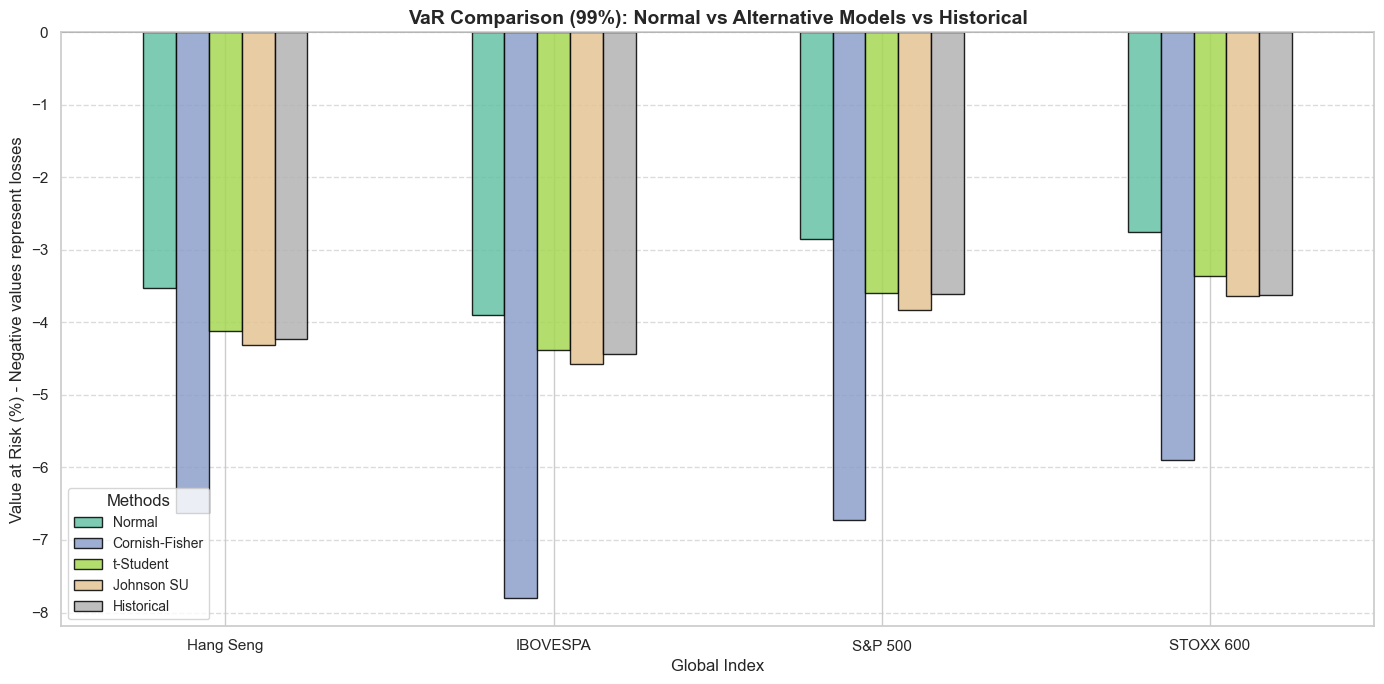

In [20]:
alpha = 0.01
confidence = 1 - alpha

results_list = []

print("="*80)
print("CALCULATING ALTERNATIVE VaR AND CVaR METHODS")
print("="*80)

# List of methods to iterate through
methods = ['Normal', 'Historical', 'Johnson SU', 't-Student', 'Cornish-Fisher']

# Iterating over each index
for col in log_market_returns.columns:
    
    # Robust check to extract a clean string name if the column is a MultiIndex tuple
    if isinstance(col, tuple):
        col_str = str(col[1]) if len(col) > 1 else str(col[0])
    else:
        col_str = str(col)
        
    # Clean returns as a Pandas Series (Safe for moments calculation)
    returns_series = log_market_returns[col].dropna()
    # As Numpy array for the Scipy distributions
    returns = returns_series.to_numpy(dtype=float)
    
    # Basic statistical moments using Pandas directly (Bulletproof approach)
    mu = returns_series.mean()
    sigma = returns_series.std(ddof=1)
    s = returns_series.skew()
    k = returns_series.kurtosis() # Pandas calculates Excess Kurtosis by default, perfectly suited for Cornish-Fisher
    
    # Iterating over the requested methods
    for method in methods:
        var_estimate = np.nan
        cvar_estimate = np.nan
        
        if method == 'Normal':
            z_alpha = stats.norm.ppf(alpha)
            var_estimate = mu + sigma * z_alpha
            cvar_estimate = mu - sigma * (stats.norm.pdf(z_alpha) / alpha)
            
        elif method == 'Historical':
            var_estimate = np.percentile(returns, alpha * 100)
            cvar_estimate = returns[returns <= var_estimate].mean()
            
        elif method == 'Johnson SU':
            # Fit the flexible Johnson SU curve using stats.johnsonsu
            a_jsu, b_jsu, loc_jsu, scale_jsu = stats.johnsonsu.fit(returns)
            var_estimate = stats.johnsonsu.ppf(alpha, a_jsu, b_jsu, loc=loc_jsu, scale=scale_jsu)
            
            # Simulation for CVaR
            sim_jsu = stats.johnsonsu.rvs(a_jsu, b_jsu, loc=loc_jsu, scale=scale_jsu, size=100000)
            cvar_estimate = sim_jsu[sim_jsu <= var_estimate].mean()
            
        elif method == 't-Student':
            # Fit the t distribution using stats.t
            df_t, loc_t, scale_t = stats.t.fit(returns)
            var_estimate = stats.t.ppf(alpha, df_t, loc=loc_t, scale=scale_t)
            
            # Simulation for CVaR
            sim_t = stats.t.rvs(df_t, loc=loc_t, scale=scale_t, size=100000)
            cvar_estimate = sim_t[sim_t <= var_estimate].mean()
            
        elif method == 'Cornish-Fisher':
            # Adjust the Z-score considering skewness (s) and kurtosis (k)
            z_alpha = stats.norm.ppf(alpha)
            z_cf = z_alpha + (1/6)*(z_alpha**2 - 1)*s + (1/24)*(z_alpha**3 - 3*z_alpha)*k - (1/36)*(2*z_alpha**3 - 5*z_alpha)*(s**2)
            var_estimate = mu + sigma * z_cf
            # Cornish-Fisher CVaR doesn't have a simple closed formula, keeping NaN
            cvar_estimate = np.nan 

        # Appending results (multiplying by 100 to visualize in %)
        results_list.append({
            'Index': col_str,
            'Method': method,
            'VaR (99%)': var_estimate * 100,
            'CVaR (99%)': cvar_estimate * 100
        })

# ==============================================================================
# RESULTS VISUALIZATION
# ==============================================================================
df_results = pd.DataFrame(results_list)

# Creating a pivot table to compare methods side by side for each index
df_var_pivot = df_results.pivot(index='Index', columns='Method', values='VaR (99%)')

# Reordering columns for better logical display
column_order = ['Normal', 'Cornish-Fisher', 't-Student', 'Johnson SU', 'Historical']

# Ensure only existing columns are reordered (prevents KeyErrors if a method failed)
column_order = [m for m in column_order if m in df_var_pivot.columns]
df_var_pivot = df_var_pivot[column_order]

print("\n--- Comparative Table: Alternative VaR Models at 99% ---")
display(df_var_pivot.round(2))

# Preparing the comparative bar chart
fig, ax = plt.subplots(figsize=(14, 7))

df_var_pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', alpha=0.85)

ax.set_title('VaR Comparison (99%): Normal vs Alternative Models vs Historical', fontsize=14, fontweight='bold')
ax.set_ylabel('Value at Risk (%) - Negative values represent losses')
ax.set_xlabel('Global Index')
ax.axhline(0, color='black', linewidth=1.2)
plt.xticks(rotation=0)
ax.legend(title='Methods', loc='lower left', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

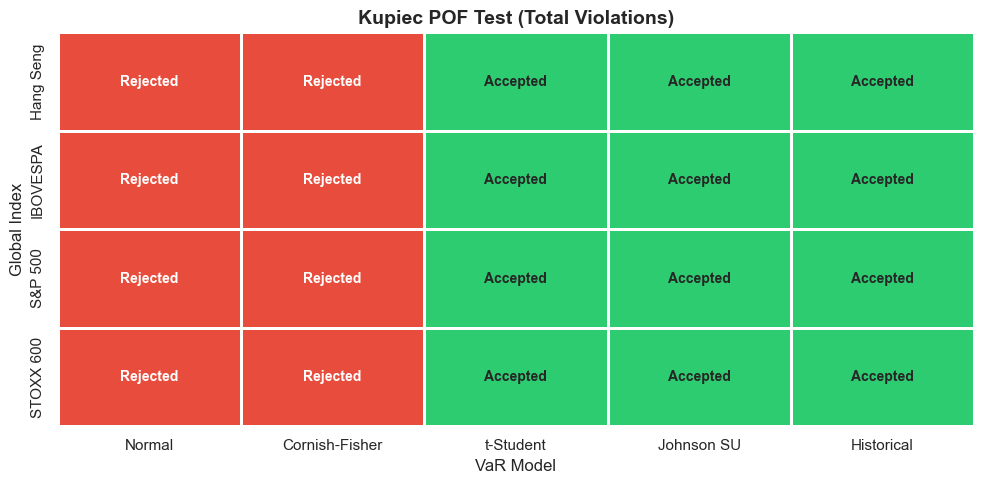


--- Kupiec Test Detailed Metrics ---


,Index,Method,Actual Violations,Expected Violations,Kupiec P-Value,Kupiec Result
0,IBOVESPA,Normal,68,48.8,0.0092,Rejected
1,IBOVESPA,Historical,49,48.8,0.9782,Accepted
2,IBOVESPA,Johnson SU,46,48.8,0.6831,Accepted
3,IBOVESPA,t-Student,51,48.8,0.7545,Accepted
4,IBOVESPA,Cornish-Fisher,12,48.8,0.0000,Rejected
5,S&P 500,Normal,108,48.8,0.0000,Rejected
6,S&P 500,Historical,49,48.8,0.9782,Accepted
7,S&P 500,Johnson SU,44,48.8,0.4816,Accepted
8,S&P 500,t-Student,51,48.8,0.7545,Accepted
9,S&P 500,Cornish-Fisher,10,48.8,0.0000,Rejected


In [21]:
# === Calculating the Kupiec Test ===
# a statistical method used to backtest Value-at-Risk (VaR) models. 
# It determines if the frequency of times an actual portfolio loss exceeds 
# its predicted VaR matches the confidence level the model claims to provid.

def kupiec_pof_test(returns, var_estimate, alpha):
    N = len(returns)
    violations = np.sum(returns < var_estimate)
    expected_violations = N * alpha
    p_hat = violations / N if N > 0 else 0

    if violations == 0:
        lr_pof = -2 * np.log((1 - alpha)**N)
    elif violations == N:
        lr_pof = -2 * np.log(alpha**N)
    else:
        lr_pof = -2 * np.log(((1 - alpha)**(N - violations)) * (alpha**violations)) + \
                  2 * np.log(((1 - p_hat)**(N - violations)) * (p_hat**violations))

    p_value = 1 - stats.chi2.cdf(lr_pof, 1)
    is_accepted = "Accepted" if p_value > 0.05 else "Rejected"

    return int(violations), expected_violations, lr_pof, p_value, is_accepted

kupiec_results = []

# Assuming df_results and log_market_returns are in memory from the VaR calculations
for index_row, row in df_results.iterrows():
    method = row['Method']
    col_str = row['Index']
    var_decimal = row['VaR (99%)'] / 100

    matched_col = None
    for col in log_market_returns.columns:
        current_col_str = str(col[1]) if isinstance(col, tuple) and len(col) > 1 else str(col[0] if isinstance(col, tuple) else col)
        if current_col_str == col_str:
            matched_col = col
            break

    if matched_col is not None:
        returns = log_market_returns[matched_col].dropna().to_numpy(dtype=float)
        viols, exp_viols, lr_kup, p_kup, res_kup = kupiec_pof_test(returns, var_decimal, alpha=0.01)

        kupiec_results.append({
            'Index': col_str,
            'Method': method,
            'Actual Violations': viols,
            'Expected Violations': round(exp_viols, 1),
            'LR_Kupiec': lr_kup, 
            'Kupiec P-Value': round(p_kup, 4),
            'Kupiec Result': res_kup
        })

df_kupiec = pd.DataFrame(kupiec_results)

# --- Plotting the Kupiec Heatmap ---
df_kupiec['Kup_Numeric'] = df_kupiec['Kupiec Result'].apply(lambda x: 1 if x == 'Accepted' else 0)
pivot_kupiec = df_kupiec.pivot(index='Index', columns='Method', values='Kup_Numeric')

column_order = ['Normal', 'Cornish-Fisher', 't-Student', 'Johnson SU', 'Historical']
column_order = [m for m in column_order if m in pivot_kupiec.columns]
pivot_kupiec = pivot_kupiec[column_order]

fig, ax = plt.subplots(figsize=(10, 5))
cmap_colors = sns.color_palette(["#e74c3c", "#2ecc71"]) # Red, Green

sns.heatmap(pivot_kupiec, annot=df_kupiec.pivot(index='Index', columns='Method', values='Kupiec Result')[column_order],
            fmt="", cmap=cmap_colors, cbar=False, linewidths=1, ax=ax, annot_kws={"weight": "bold", "size": 10})

ax.set_title('Kupiec POF Test (Total Violations)', fontsize=14, fontweight='bold')
ax.set_ylabel('Global Index')
ax.set_xlabel('VaR Model')
plt.tight_layout()
plt.show()

print("\n--- Kupiec Test Detailed Metrics ---")
display(df_kupiec.drop(columns=['Kup_Numeric', 'LR_Kupiec']))

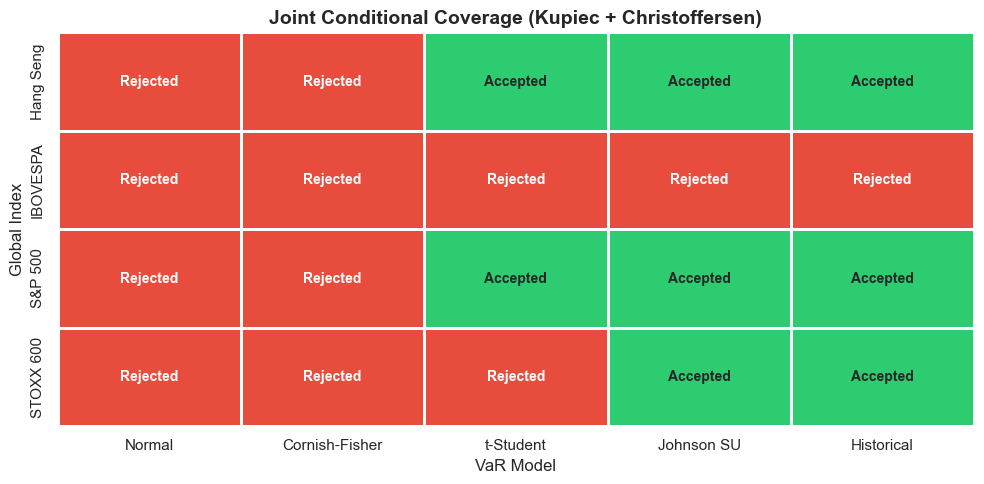


--- Joint Conditional Coverage Summary ---


Method,Normal,Cornish-Fisher,t-Student,Johnson SU,Historical
Index,,,,,
Hang Seng,Rejected,Rejected,Accepted,Accepted,Accepted
IBOVESPA,Rejected,Rejected,Rejected,Rejected,Rejected
S&P 500,Rejected,Rejected,Accepted,Accepted,Accepted
STOXX 600,Rejected,Rejected,Rejected,Accepted,Accepted



--- Detail Metrics ---


KeyError: "['pivot_joint'] not in index"

In [22]:
# === Christoffersen Test (Independence) ===
# The reason for applying Christoffersen test is to verify when the loss
# in VaR and CVaR happens. 

def christoffersen_test(returns, var_estimations, alpha):

    N = len(returns)
    hits = (returns < var_estimate).astype(int)

    # Counting transitions: T00, T01, T10, T11
    # T01 means: No violation today (0), followed by Violation tomorrow (1)
    
    T00 = T01 = T10 = T11 = 0
    for i in range(1, N):
        if hits[i-1] == 0 and hits[i] == 0: T00 += 1
        elif hits[i-1] == 0 and hits[i] == 1: T01 += 1
        elif hits[i-1] == 1 and hits[i] == 0: T10 += 1
        elif hits[i-1] == 1 and hits[i] == 1: T11 += 1

    pi_01 = T01 / (T00 + T01) if (T00 + T01) > 0 else 0
    pi_11 = T11 / (T10 + T11) if (T10 + T11) > 0 else 0
    pi_hat = (T01 + T11) / (T00 + T01 + T10 + T11) if (T00 + T01 + T10 + T11) > 0 else 0

    try:
        log_L_null = (T00 + T10) * np.log(1 - pi_hat) + (T01 + T11) * np.log(pi_hat)
        log_L_alt = T00 * np.log(1 - pi_01) + T01 * np.log(pi_01) + \
                    T10 * np.log(1 - pi_11) + (T11 * np.log(pi_11) if pi_11 > 0 else 0)

        lr_ind = -2 * (log_L_null - log_L_alt)
        p_value = 1 - stats.chi2.cdf(lr_ind, 1)
    except:
        lr_ind = 0
        p_value = 1.0

    is_accepted = "Accepted" if p_value > 0.05 else "Rejected"
    return lr_ind, p_value, is_accepted
    
christoffersen_results = []

for index_row, row in df_results.iterrows():
    method = row['Method']
    col_str = row['Index']
    var_decimal = row['VaR (99%)'] / 100

    lr_kupiec = df_kupiec[(df_kupiec['Index'] == col_str) & (df_kupiec['Method'] == method)]['LR_Kupiec'].values[0]

    matched_col = None
    for col in log_market_returns.columns:
        current_col_str = str(col[1]) if isinstance(col, tuple) and len(col) > 1 else str(col[0] if isinstance(col, tuple) else col)
        if current_col_str == col_str:
            matched_col = col
            break

    if matched_col is not None:
        returns = log_market_returns[matched_col].dropna().to_numpy(dtype=float)
        lr_chr, p_chr, res_chr = christoffersen_test(returns, var_decimal, alpha)

        # Joint Test Calculation
        lr_joint = lr_kupiec + lr_chr
        p_joint = 1 - stats.chi2.cdf(lr_joint, 2)
        res_joint = "Accepted" if p_joint > 0.05 else "Rejected"

        christoffersen_results.append({
            'Index': col_str,
            'Method': method,
            'Christoffersen P-Value': round(p_chr, 4),
            'Christoffersen Result': res_chr,
            'Joint Coverage Result': res_joint
        })

df_chr = pd.DataFrame(christoffersen_results)

# --- Plotting the Christoffersen Heatmap ---
df_chr['Joint_Numeric'] = df_chr['Joint Coverage Result'].apply(lambda x: 1 if x == 'Accepted' else 0)
pivot_joint = df_chr.pivot(index='Index', columns='Method', values='Joint_Numeric')

column_order = ['Normal', 'Cornish-Fisher', 't-Student', 'Johnson SU', 'Historical']
column_order = [m for m in column_order if m in pivot_joint.columns]
pivot_joint = pivot_joint[column_order]

fig, ax = plt.subplots(figsize=(10, 5))
cmap_colors = sns.color_palette(["#e74c3c", "#2ecc71"]) # Red, Green

sns.heatmap(pivot_joint, annot=df_chr.pivot(index='Index', columns='Method', values='Joint Coverage Result')[column_order],
            fmt="", cmap=cmap_colors, cbar=False, linewidths=1, ax=ax, annot_kws={"weight": "bold", "size": 10})

ax.set_title('Joint Conditional Coverage (Kupiec + Christoffersen)', fontsize=14, fontweight='bold')
ax.set_ylabel('Global Index')
ax.set_xlabel('VaR Model')
plt.tight_layout()
plt.show()

print("\n--- Joint Conditional Coverage Summary ---")
display(df_chr.pivot(index='Index', columns='Method', values='Joint Coverage Result')[column_order])

print("\n--- Detail Metrics ---")
display(df_chr[['Index', 'Method', 'Christoffersen Result', 'pivot_joint', 'Joint Coverage Result']])
